In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [3]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [4]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month

monthly_df = (
    df.groupby(['store_name', 'year', 'month'])['sales_amount_realistic']
    .sum()
    .reset_index()
)

monthly_df['date'] = pd.to_datetime(
    monthly_df[['year', 'month']].assign(day=1)
)

monthly_df = monthly_df.sort_values(['store_name', 'date'])

In [5]:
monthly_df['store_id'] = monthly_df['store_name'].astype('category').cat.codes

In [6]:
monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df['month'] / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df['month'] / 12)

In [7]:
for lag in [1,3,6,12]:
    monthly_df[f'lag_{lag}'] = (
        monthly_df.groupby('store_id')['sales_amount_realistic']
        .shift(lag)
    )

In [8]:
monthly_df['rolling_mean_3'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(3).mean().reset_index(0, drop=True)
)

monthly_df['rolling_mean_6'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(6).mean().reset_index(0, drop=True)
)

In [9]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [10]:
feature_cols = [
    'store_id',
    'month_sin',
    'month_cos',
    'lag_1',
    'lag_3',
    'lag_6',
    'lag_12',
    'rolling_mean_3',
    'rolling_mean_6'
]

In [11]:
def create_sequences_multi(X, y, input_window=12, output_window=12):
    X_seq, y_seq = [], []

    for i in range(len(X) - input_window - output_window + 1):
        X_seq.append(X[i:i+input_window])
        y_seq.append(y[i+input_window:i+input_window+output_window])

    return np.array(X_seq), np.array(y_seq)

In [12]:
X_all = []
y_all = []
store_ids_per_sample = []

for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[monthly_df['store_id'] == store_id]
    
    X = store_data[feature_cols].values
    y = store_data['sales_amount_realistic'].values
    
    X_seq, y_seq = create_sequences_multi(X, y)
    
    X_all.append(X_seq)
    y_all.append(y_seq)
    
    store_ids_per_sample.extend([store_id] * len(X_seq))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
store_ids_per_sample = np.array(store_ids_per_sample)

In [13]:
split = int(len(X_all) * 0.8)

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

store_ids_train = store_ids_per_sample[:split]
store_ids_test = store_ids_per_sample[split:]

In [14]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [15]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(12, len(feature_cols))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(12)   # 🔥 12 شهر مرة واحدة
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

d:\anaconda\envs\Apple\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,756 (124.05 KB)

 Trainable params: 31,756 (124.05 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5846 - mae: 0.5743 - val_loss: 0.2398 - val_mae: 0.3767
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3187 - mae: 0.4067 - val_loss: 0.2232 - val_mae: 0.3534
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2611 - mae: 0.3718 - val_loss: 0.2031 - val_mae: 0.3283
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2404 - mae: 0.3588 - val_loss: 0.1986 - val_mae: 0.3235
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2375 - mae: 0.3551 - val_loss: 0.1789 - val_mae: 0.3104
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2243 - mae: 0.3485 - val_loss: 0.1757 - val_mae: 0.3088
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2221 - mae: 0.3474 - val_loss: 0.1743 - val_mae: 0.3084
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2148 - mae: 0.3417 - val_loss: 0.1877 - val_mae: 0.3306
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.21

In [17]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
r2 = r2_score(y_true.flatten(), y_pred.flatten())

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAE: 248893.90038308725
RMSE: 314278.47300255456
R2: 0.892142381560838


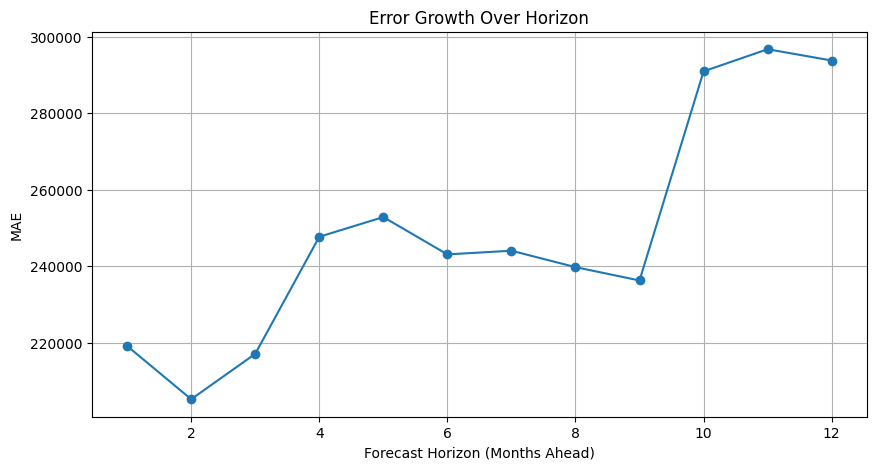

In [23]:
horizon_mae = []

for i in range(12):
    mae_i = np.mean(np.abs(y_true[:, i] - y_pred[:, i]))
    horizon_mae.append(mae_i)

plt.figure(figsize=(10,5))
plt.plot(range(1,13), horizon_mae, marker='o')
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("MAE")
plt.title("Error Growth Over Horizon")
plt.grid(True)
plt.show()

In [24]:
store_errors = []

for store_id in np.unique(store_ids_test):
    
    mask = store_ids_test == store_id
    
    true_store = y_true[mask]
    pred_store = y_pred[mask]
    
    mae_store = np.mean(np.abs(true_store - pred_store))
    
    store_errors.append((store_id, mae_store))

store_error_df = pd.DataFrame(
    store_errors,
    columns=["store_id", "MAE"]
).sort_values("MAE", ascending=False)

store_error_df.head()

,store_id,MAE
12,67,330293.633906
0,55,329282.891649
13,68,304125.412318
10,65,291709.676759
11,66,286094.167000


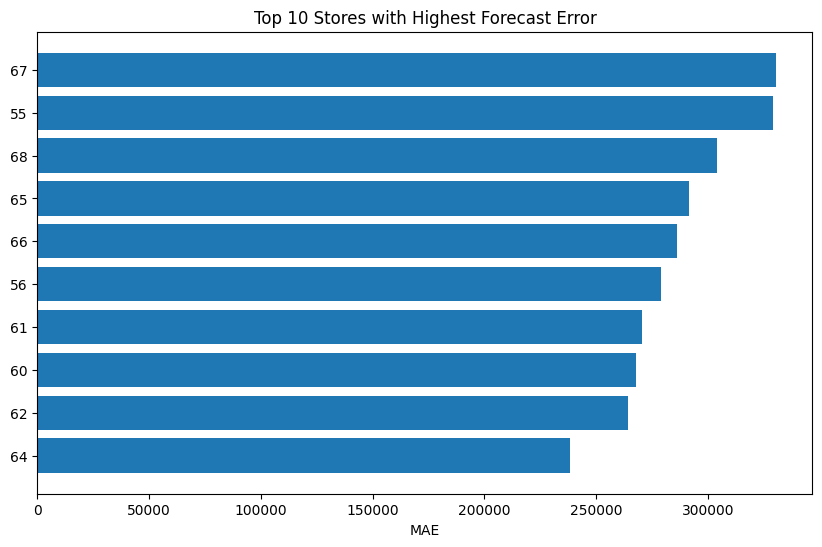

In [25]:
top_worst = store_error_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_worst['store_id'].astype(str), top_worst['MAE'])
plt.xlabel("MAE")
plt.title("Top 10 Stores with Highest Forecast Error")
plt.gca().invert_yaxis()
plt.show()

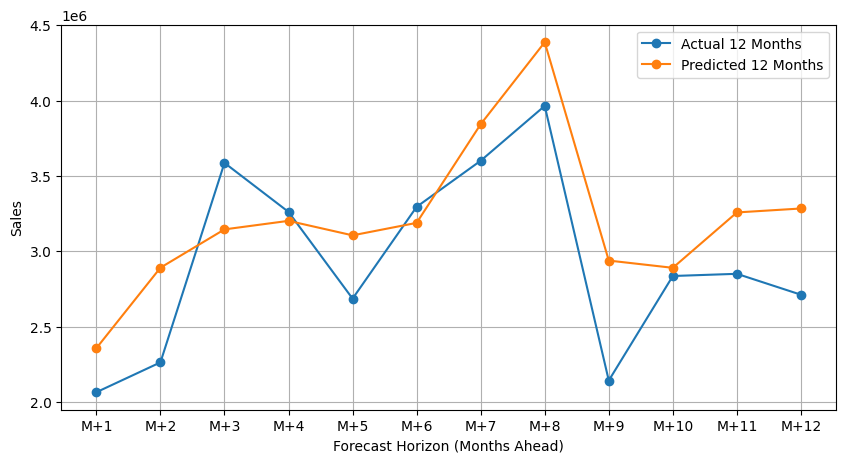

In [18]:
months = np.arange(1, 13)
months = [f"M+{i}" for i in range(1,13)]
plt.figure(figsize=(10,5))

plt.plot(months, y_true[0], marker='o', label="Actual 12 Months")
plt.plot(months, y_pred[0], marker='o', label="Predicted 12 Months")

plt.xticks(months)
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_true.shape   # (samples, 12)
y_pred.shape   # (samples, 12)

(332, 12)

In [20]:
import numpy as np
import pandas as pd

horizon_mae = []
horizon_rmse = []
horizon_r2 = []

for i in range(12):
    
    true_i = y_true[:, i]
    pred_i = y_pred[:, i]
    
    mae_i = np.mean(np.abs(true_i - pred_i))
    rmse_i = np.sqrt(np.mean((true_i - pred_i)**2))
    r2_i = 1 - (np.sum((true_i - pred_i)**2) / np.sum((true_i - np.mean(true_i))**2))
    
    horizon_mae.append(mae_i)
    horizon_rmse.append(rmse_i)
    horizon_r2.append(r2_i)

horizon_df = pd.DataFrame({
    "Horizon": range(1,13),
    "MAE": horizon_mae,
    "RMSE": horizon_rmse,
    "R2": horizon_r2
})

horizon_df

,Horizon,MAE,RMSE,R2
0,1,219128.266444,284089.780998,0.911817
1,2,205197.226941,265677.811067,0.923076
2,3,217069.253998,274119.793308,0.918429
3,4,247700.624216,309067.183939,0.895626
4,5,252863.001457,314578.264746,0.890742
5,6,243089.389476,306586.601231,0.896744
6,7,244055.951915,301665.168340,0.899890
7,8,239757.989668,294673.501752,0.904175
8,9,236270.664650,309323.929670,0.893707
9,10,290992.179449,357470.268510,0.859807


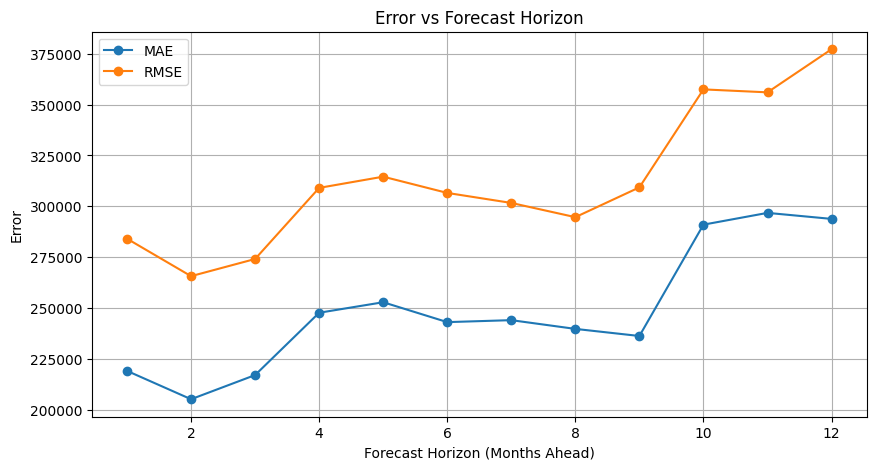

In [21]:
plt.figure(figsize=(10,5))

plt.plot(range(1,13), horizon_mae, marker='o', label='MAE')
plt.plot(range(1,13), horizon_rmse, marker='o', label='RMSE')

plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Error")
plt.title("Error vs Forecast Horizon")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
def forecast_2025_for_store(store_id):

    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date').copy()

    last_12 = store_data.tail(12)

    X_input = last_12[feature_cols].values
    X_input_scaled = scaler.transform(X_input)
    X_input_scaled = X_input_scaled.reshape(1, 12, len(feature_cols))

    y_pred_scaled = model.predict(X_input_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)[0]

    last_date = last_12['date'].iloc[-1]

    future_dates = [
        last_date + pd.DateOffset(months=i+1)
        for i in range(12)
    ]

    forecast_df = pd.DataFrame({
        "store_id": store_id,
        "date": future_dates,
        "forecast_2025": y_pred
    })

    return forecast_df

In [27]:
forecast_all_2025 = []

for store_id in monthly_df['store_id'].unique():
    forecast_store = forecast_2025_for_store(store_id)
    forecast_all_2025.append(forecast_store)

forecast_all_2025 = pd.concat(forecast_all_2025).reset_index(drop=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

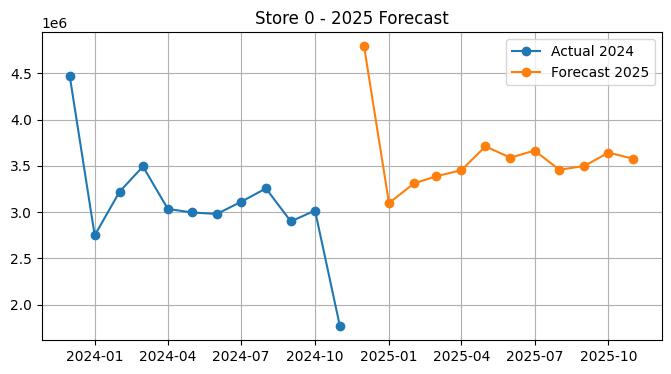

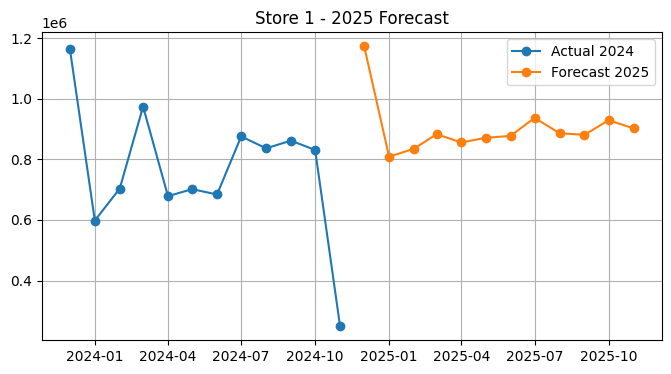

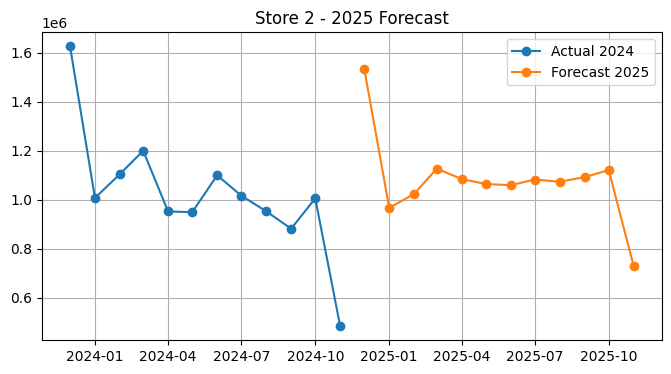

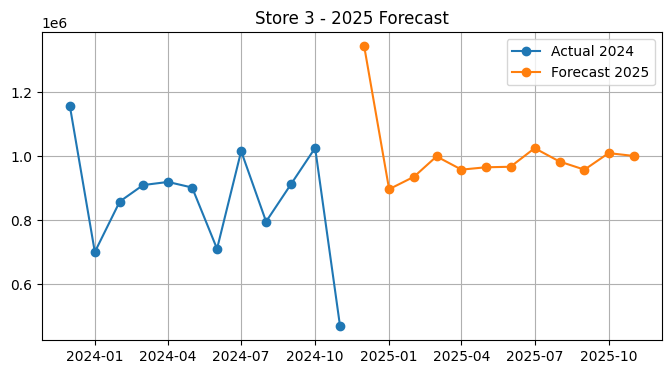

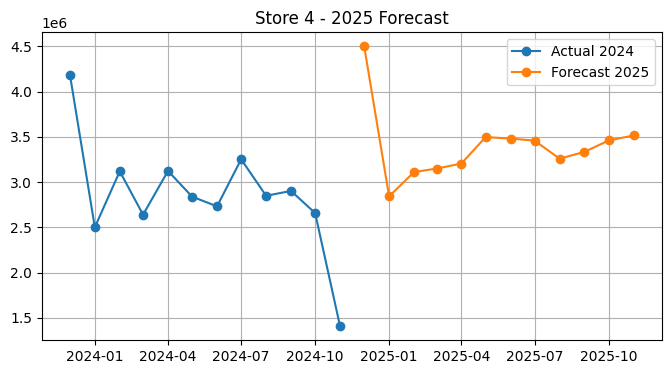

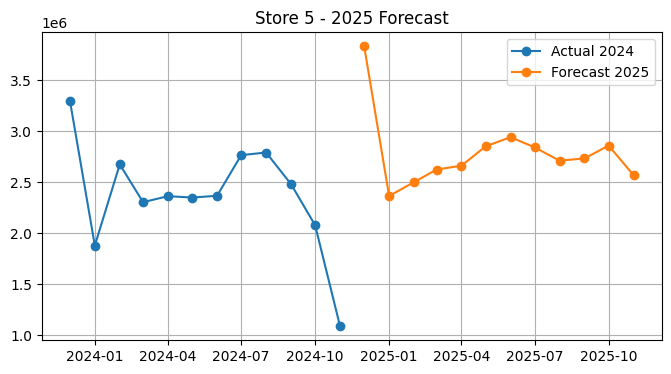

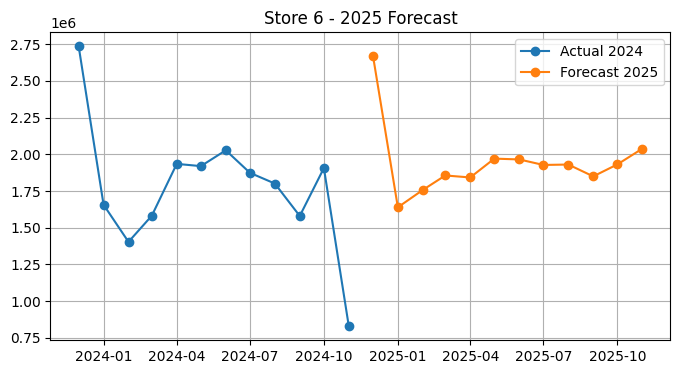

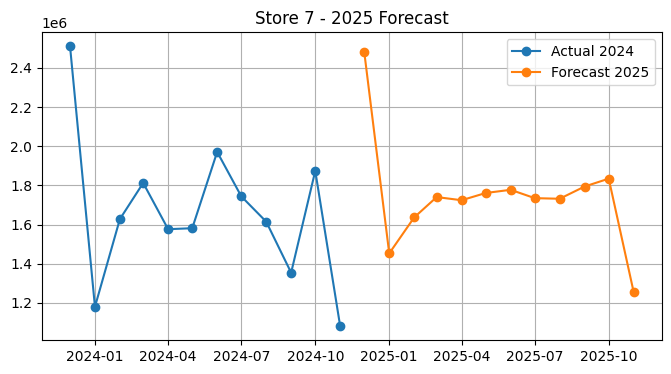

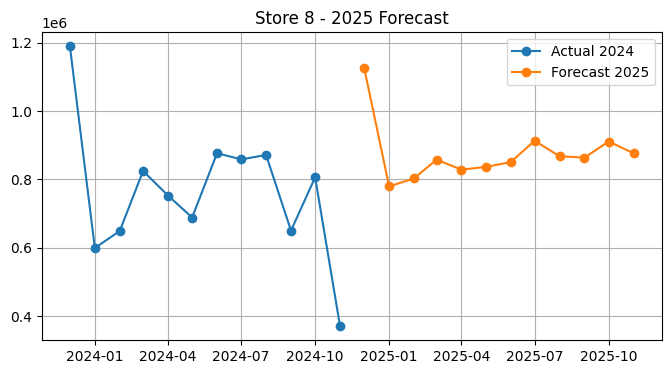

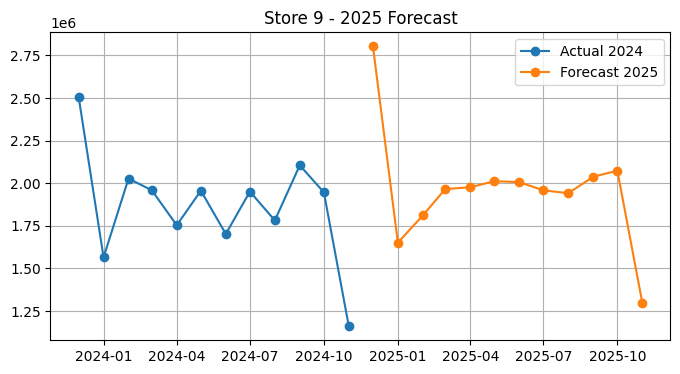

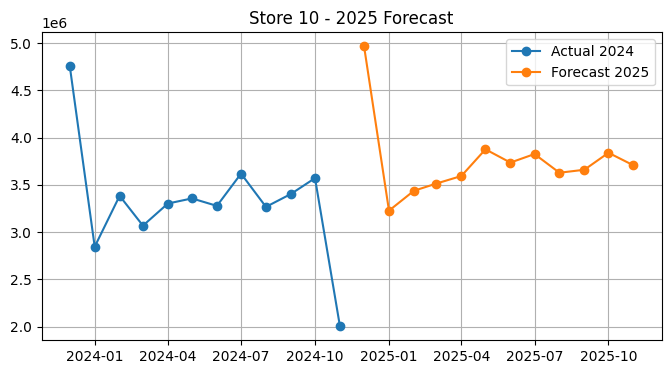

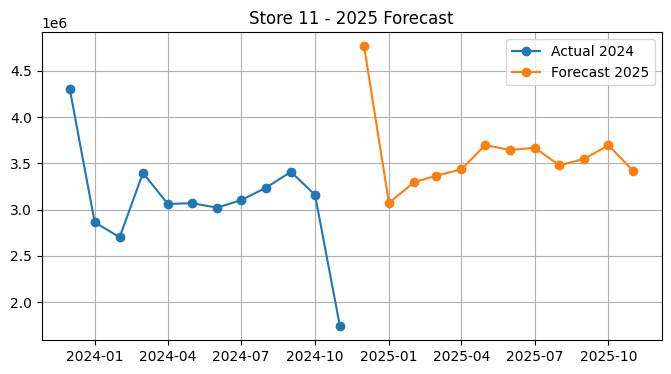

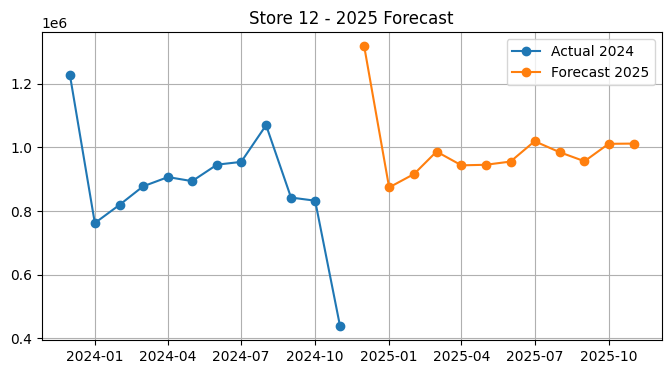

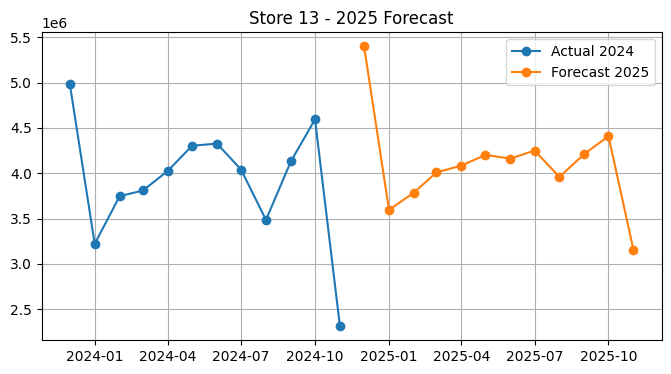

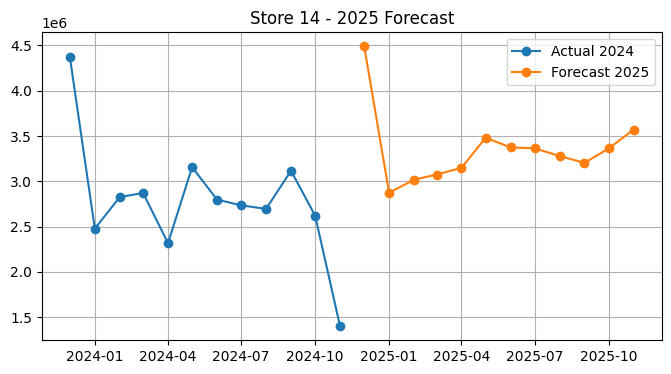

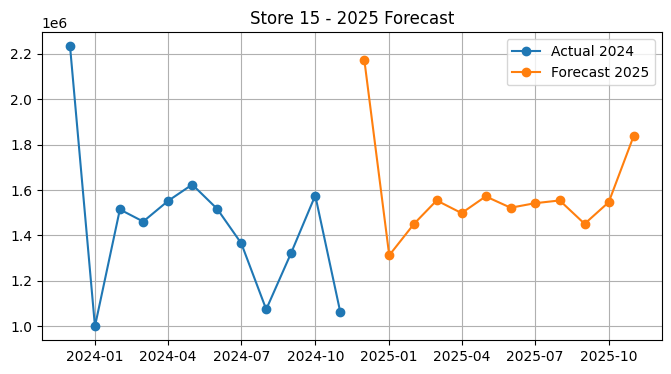

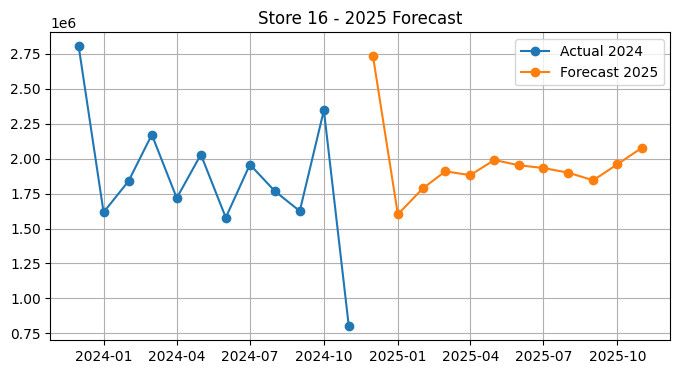

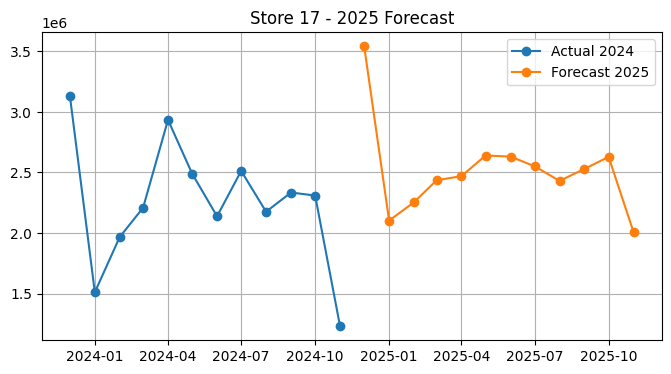

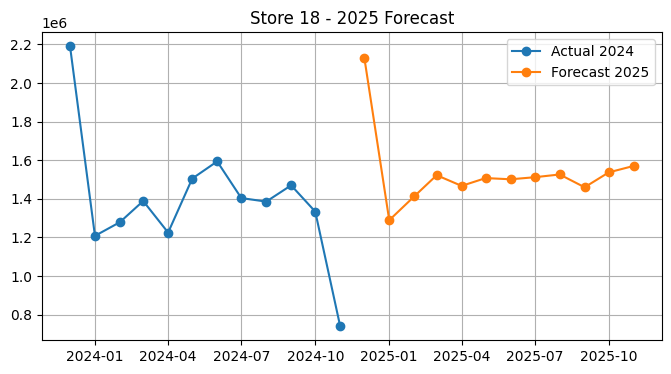

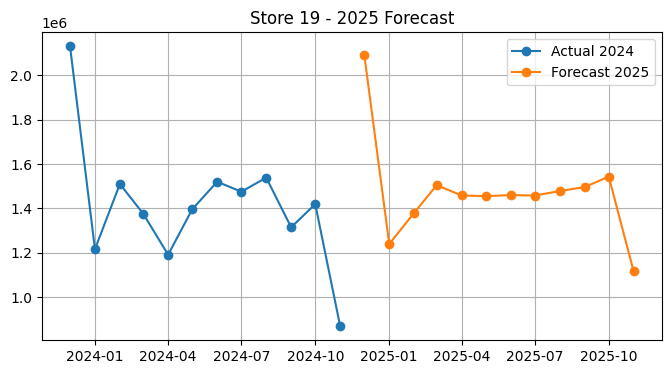

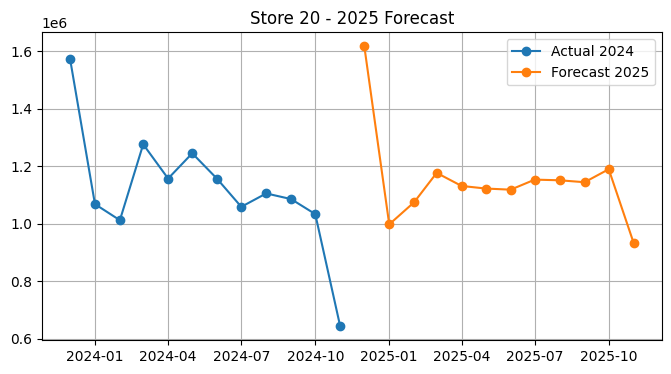

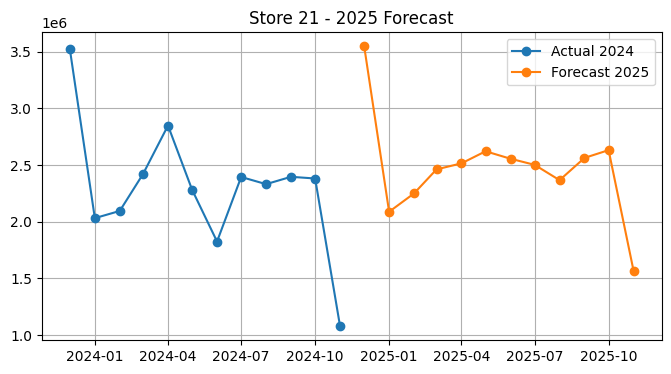

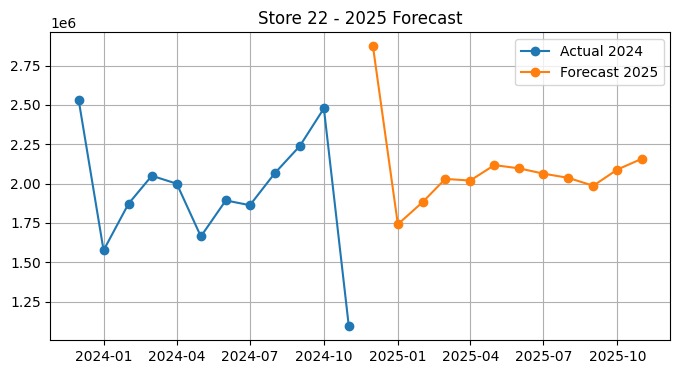

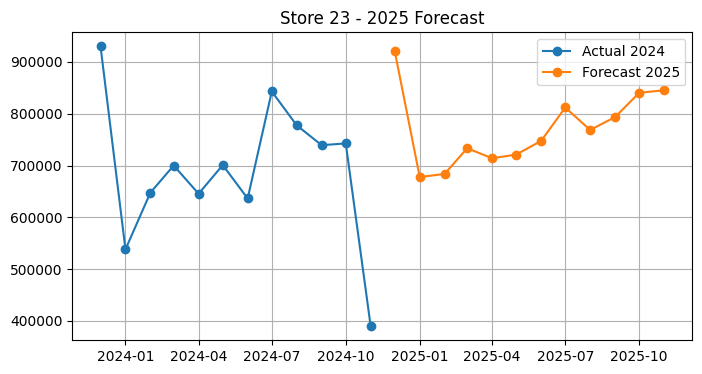

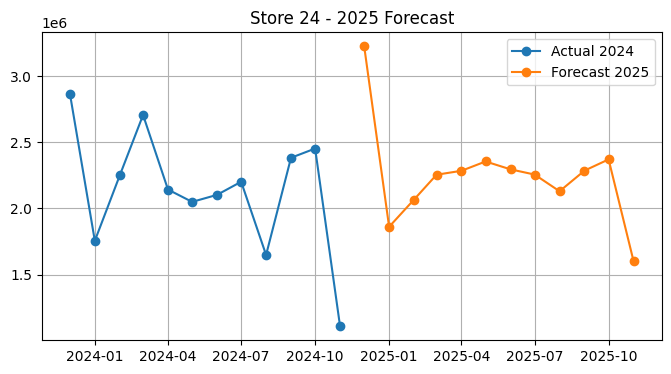

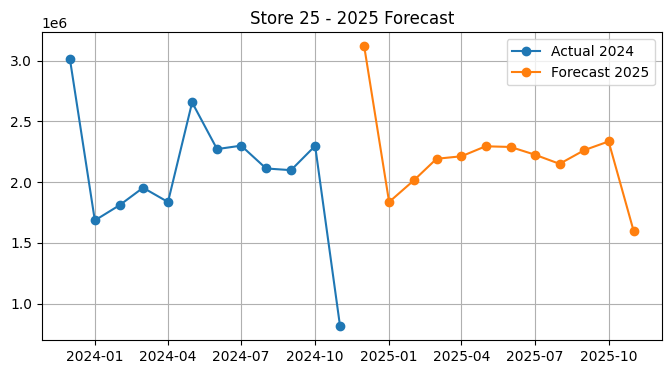

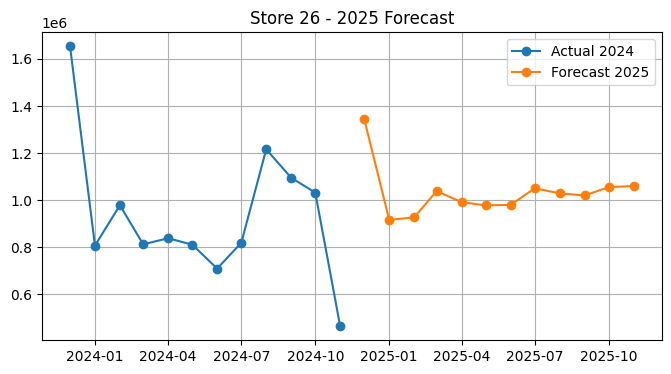

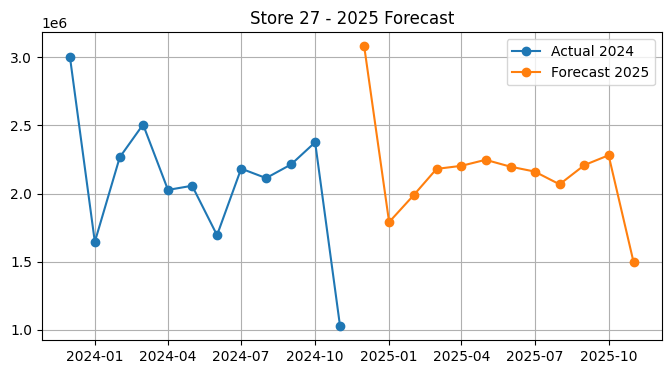

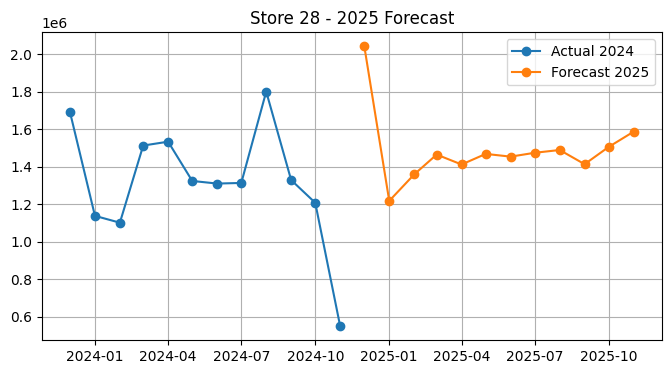

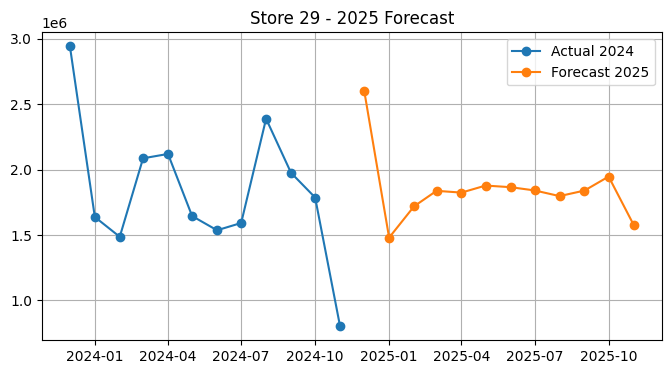

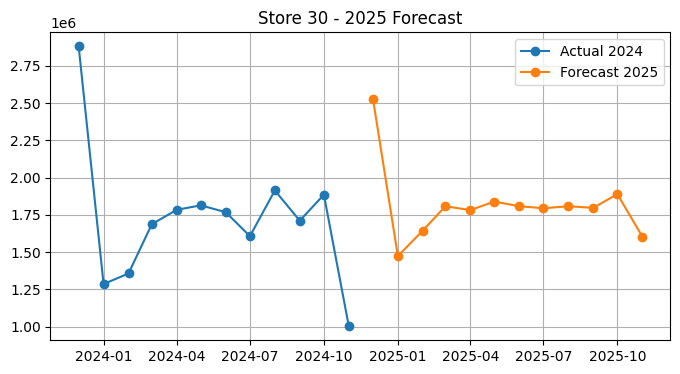

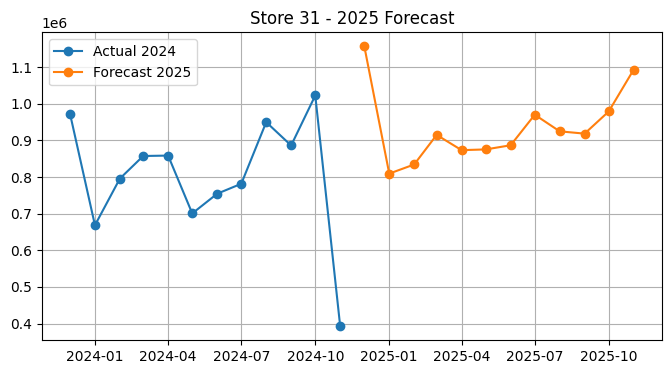

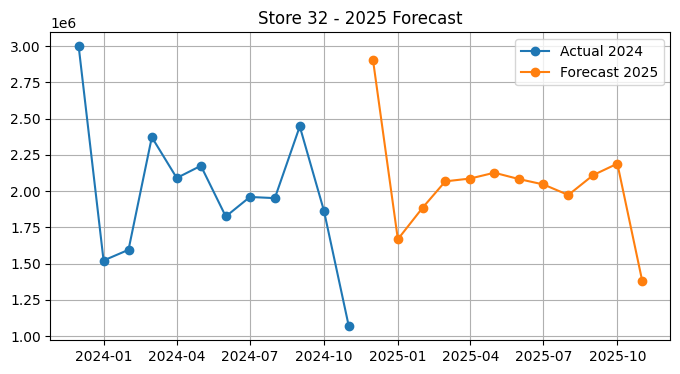

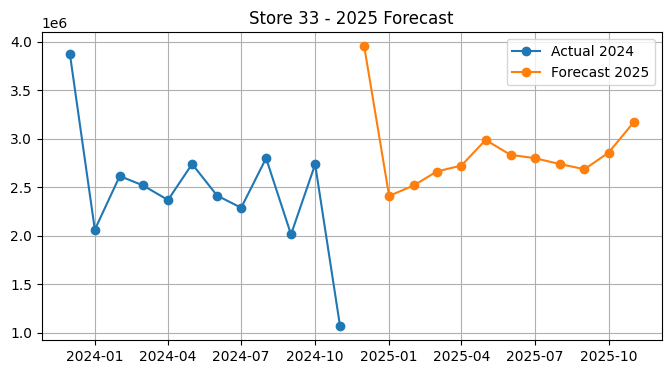

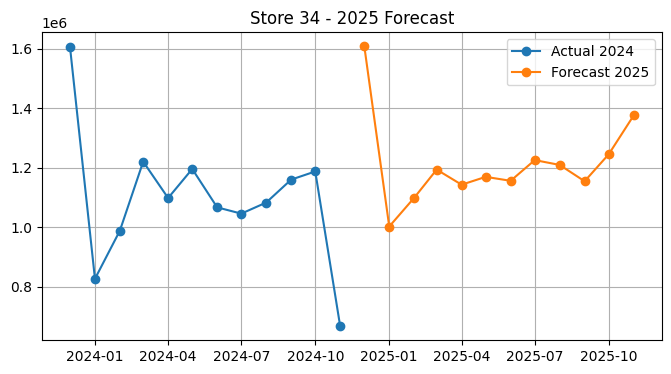

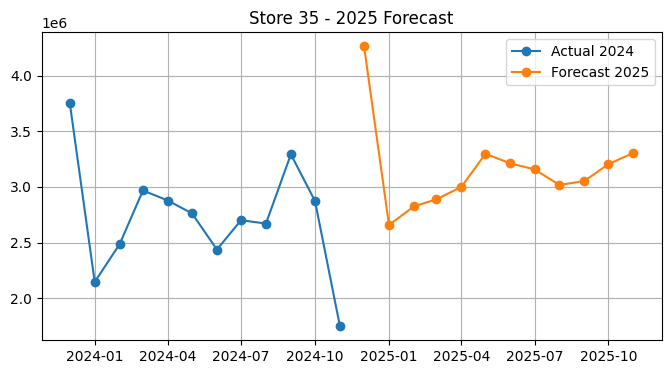

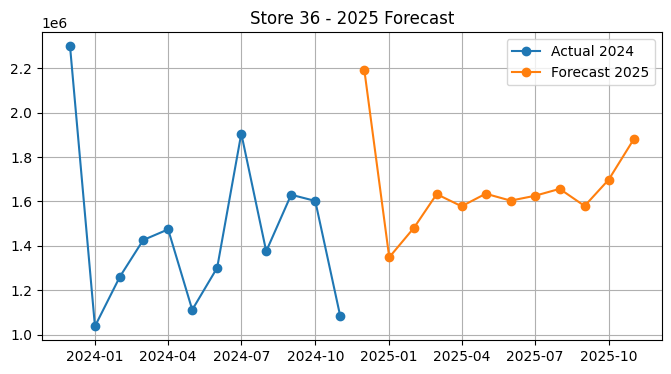

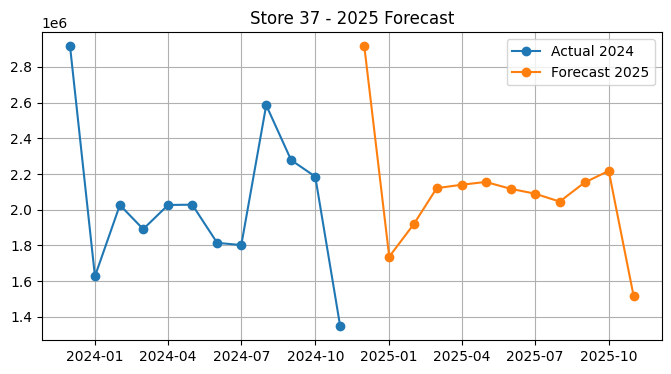

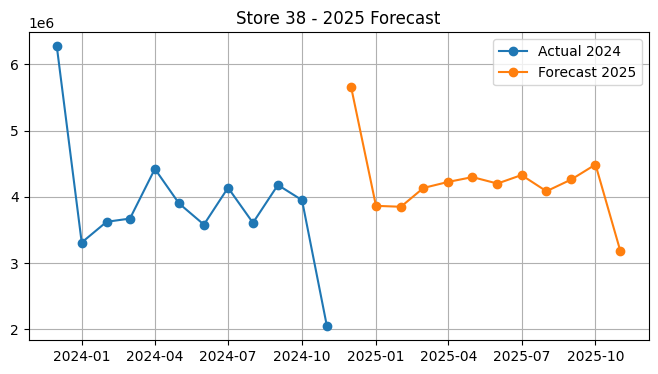

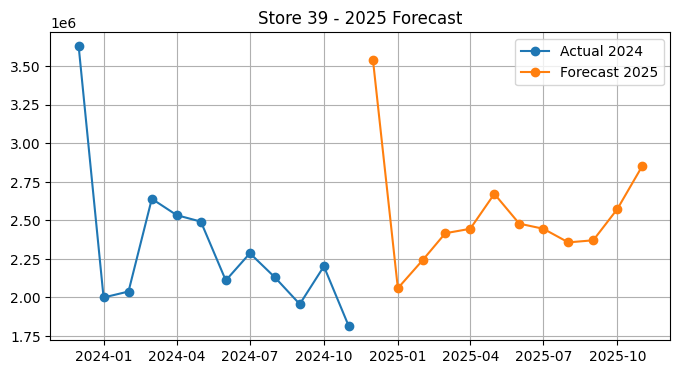

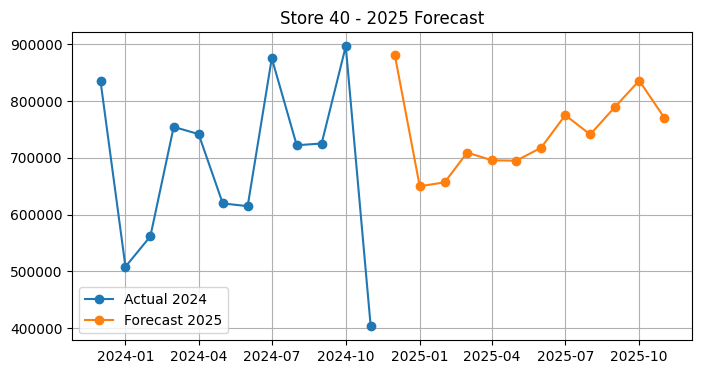

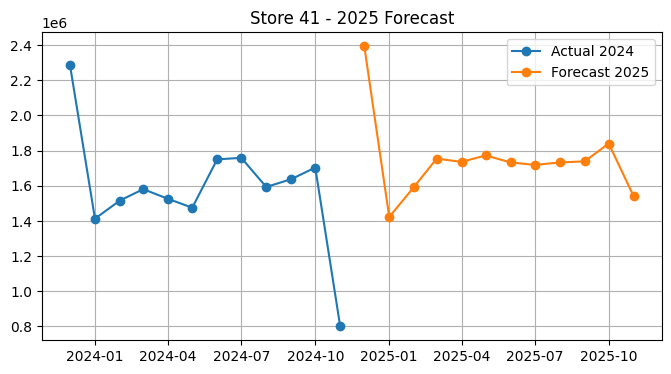

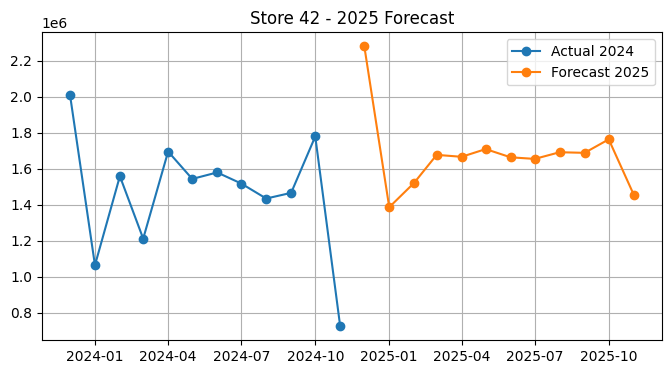

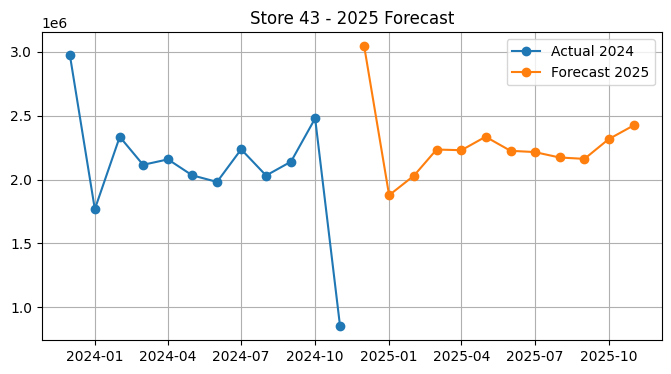

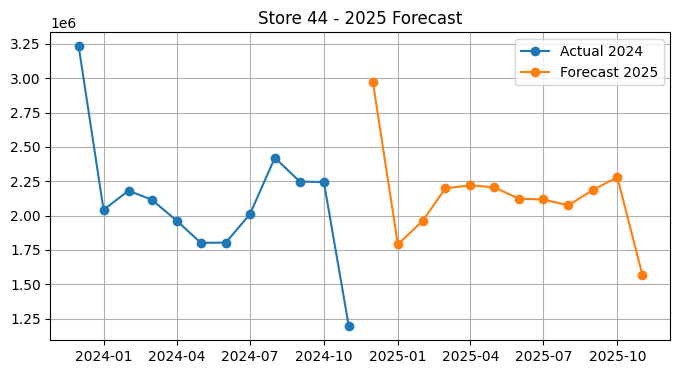

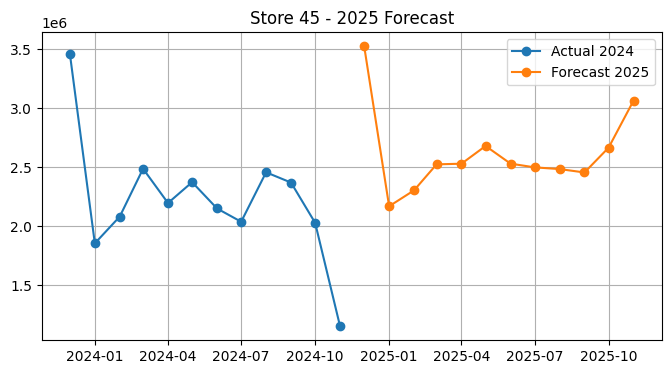

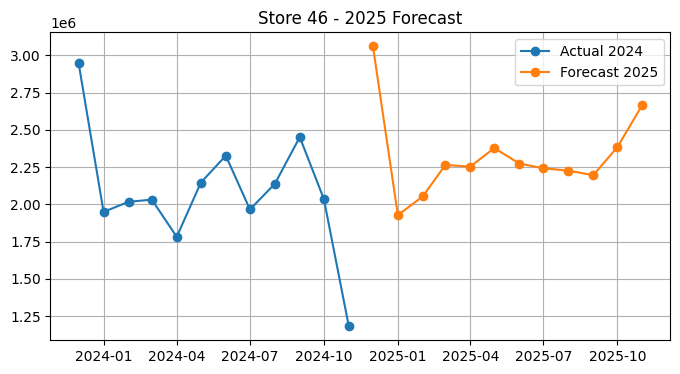

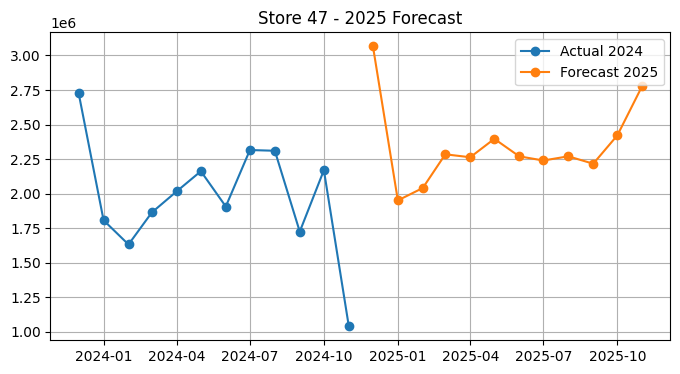

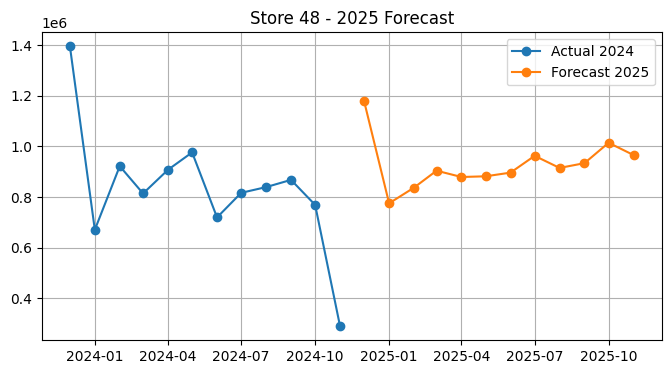

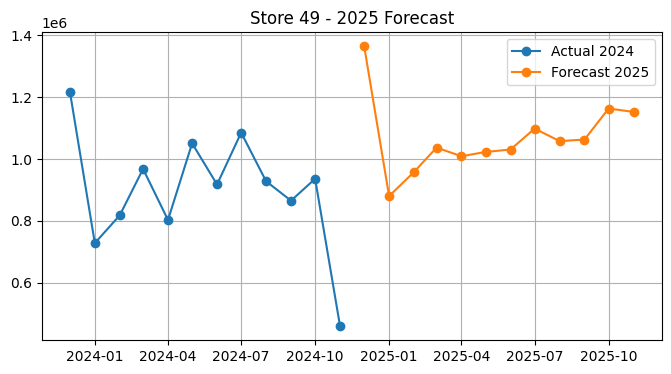

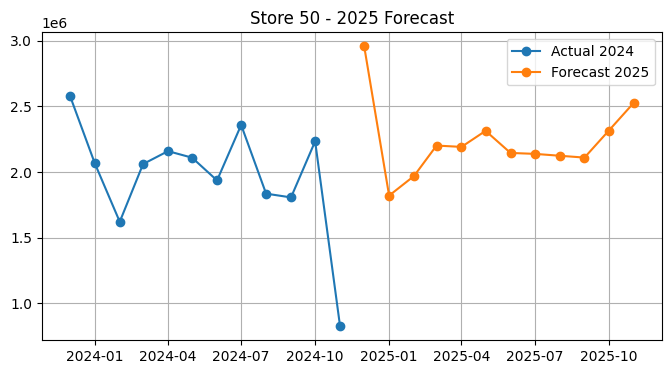

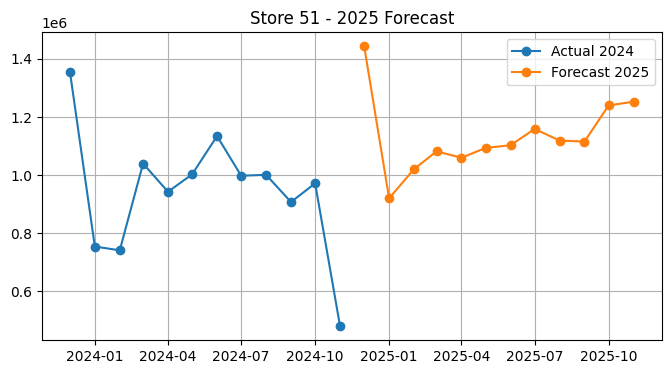

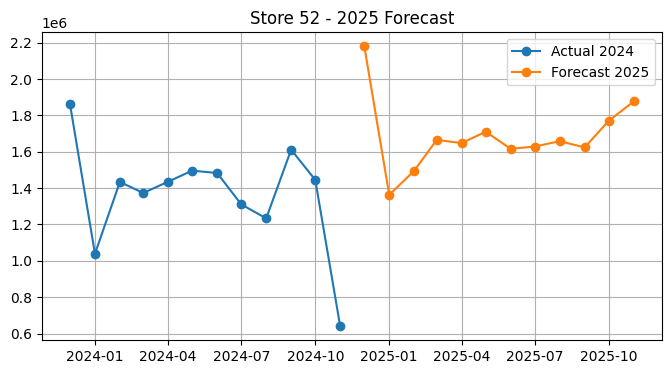

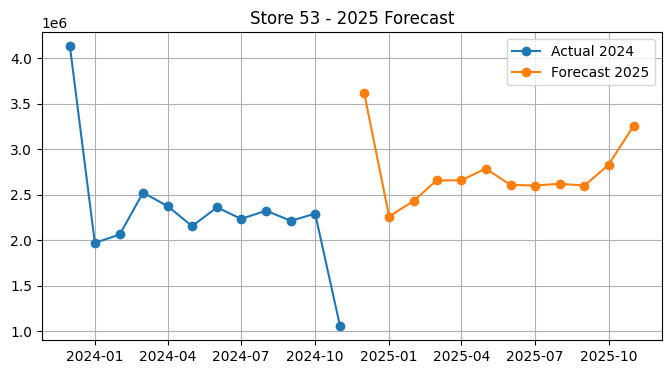

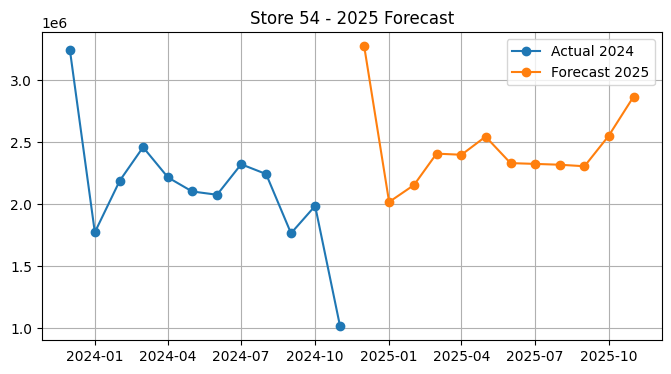

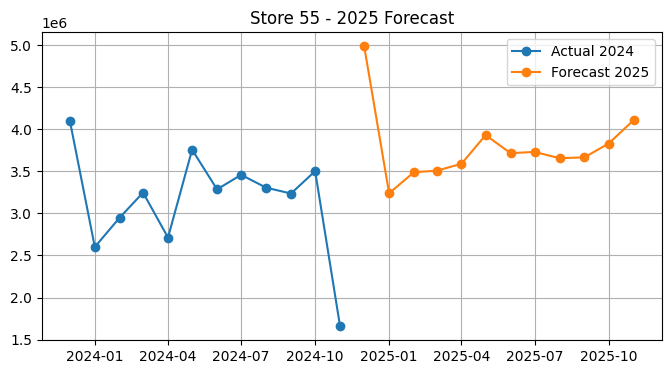

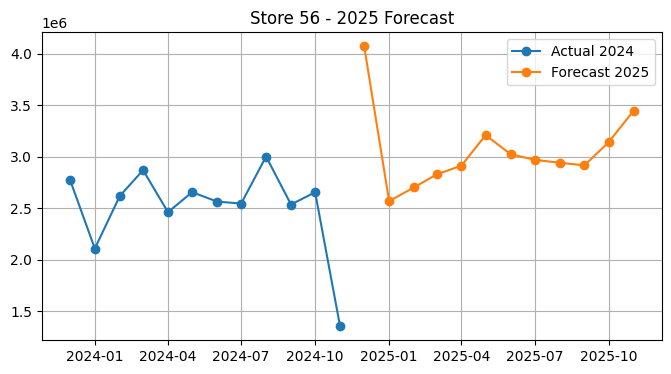

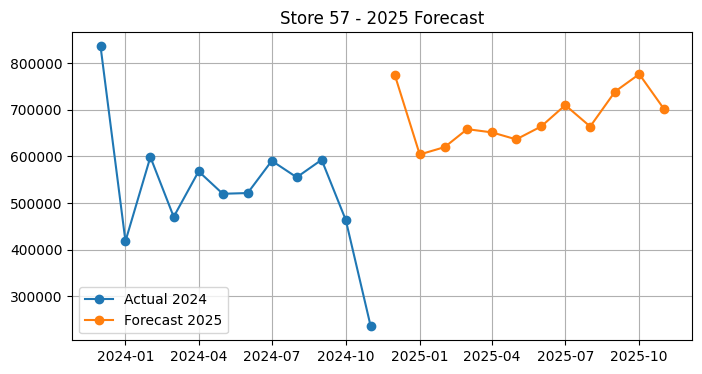

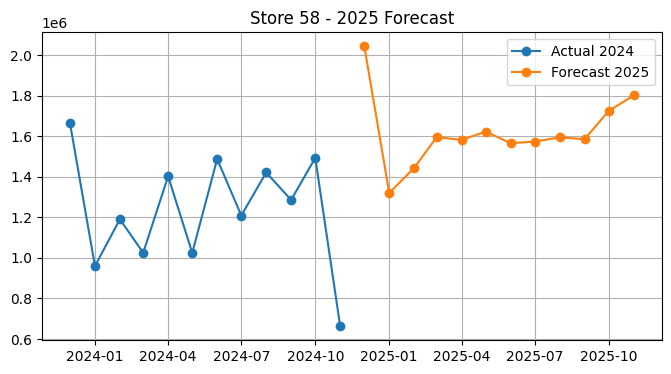

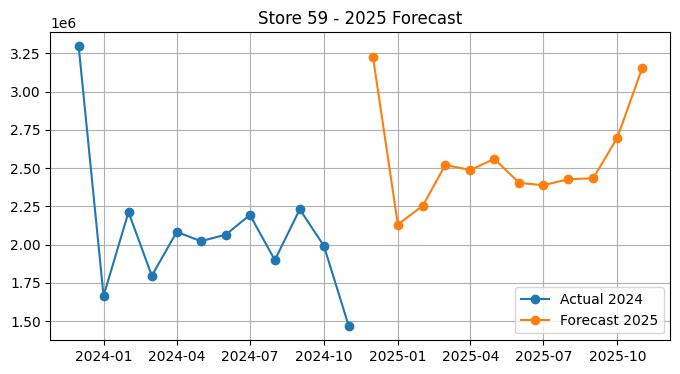

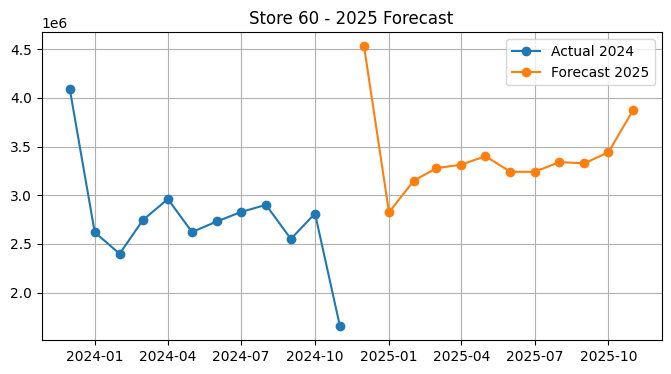

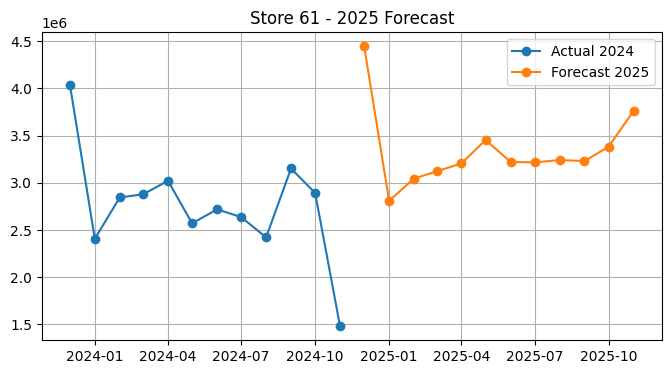

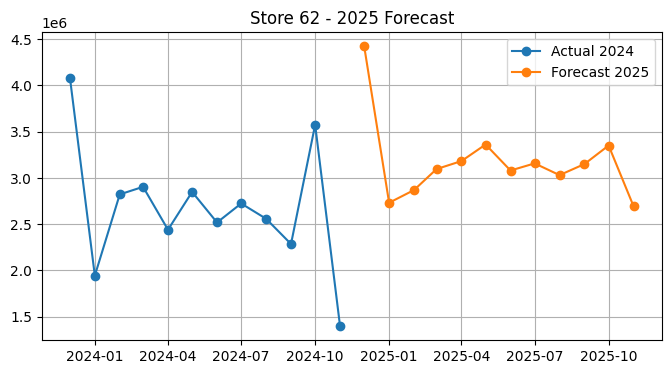

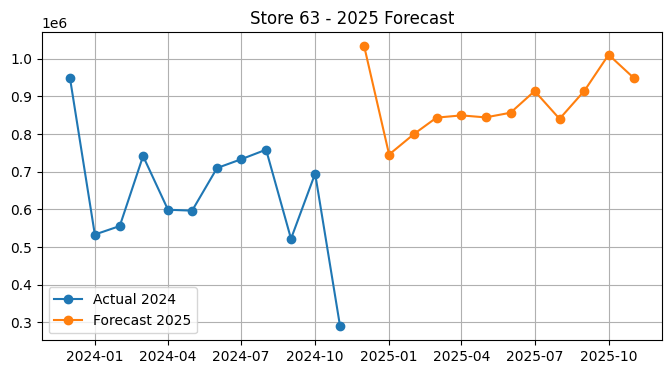

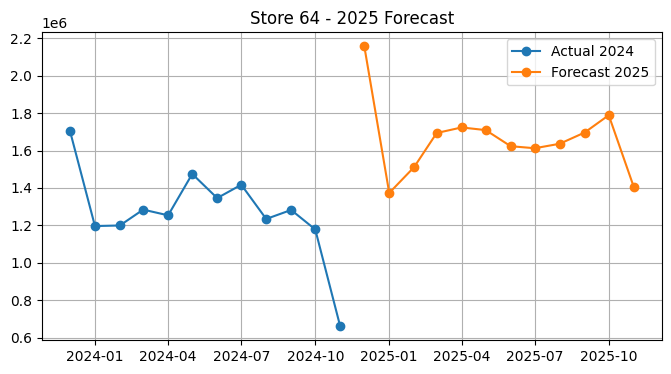

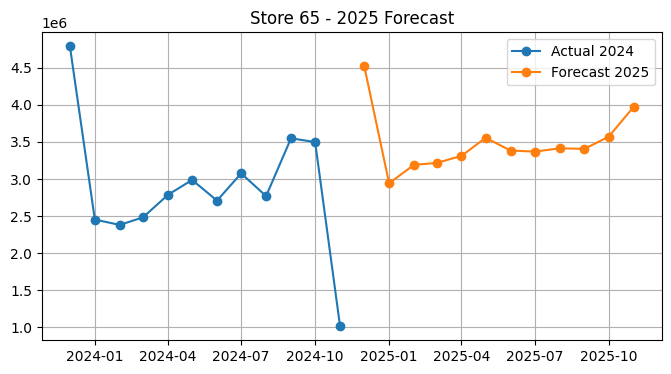

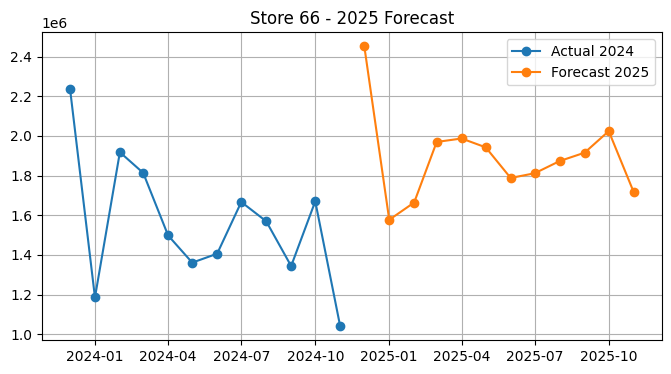

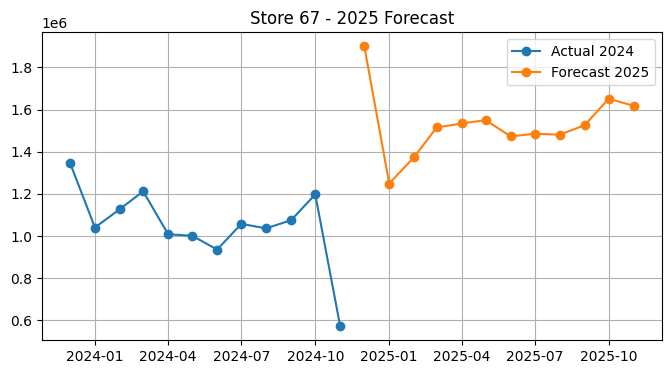

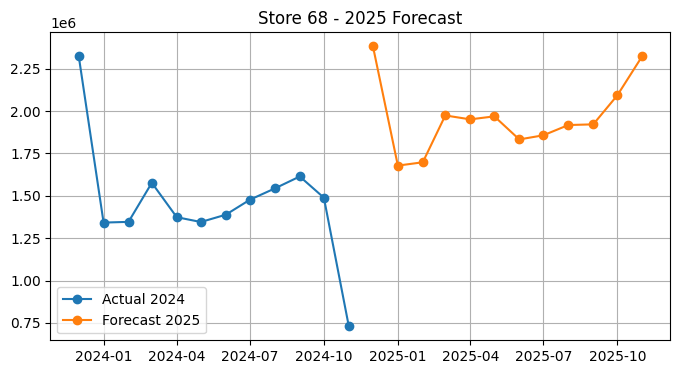

In [28]:
for store_id in monthly_df['store_id'].unique():

    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date')

    forecast_store = forecast_all_2025[
        forecast_all_2025['store_id'] == store_id
    ]

    plt.figure(figsize=(8,4))

    plt.plot(
        store_data['date'].tail(12),
        store_data['sales_amount_realistic'].tail(12),
        marker='o',
        label='Actual 2024'
    )

    plt.plot(
        forecast_store['date'],
        forecast_store['forecast_2025'],
        marker='o',
        label='Forecast 2025'
    )

    plt.title(f"Store {store_id} - 2025 Forecast")
    plt.legend()
    plt.grid(True)
    plt.show()

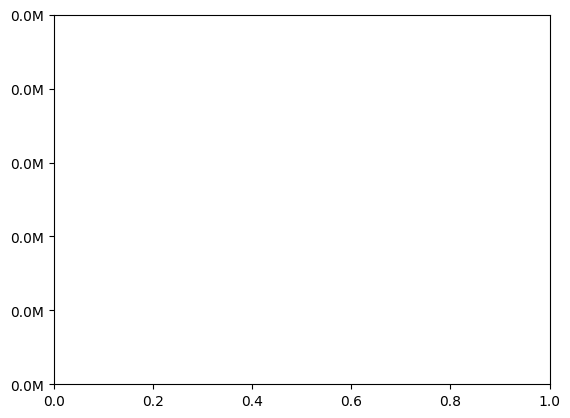

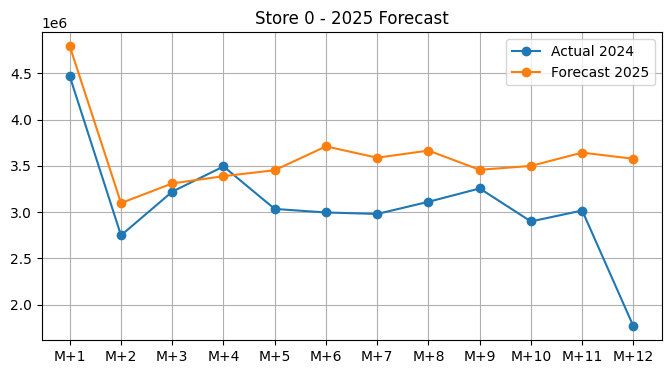

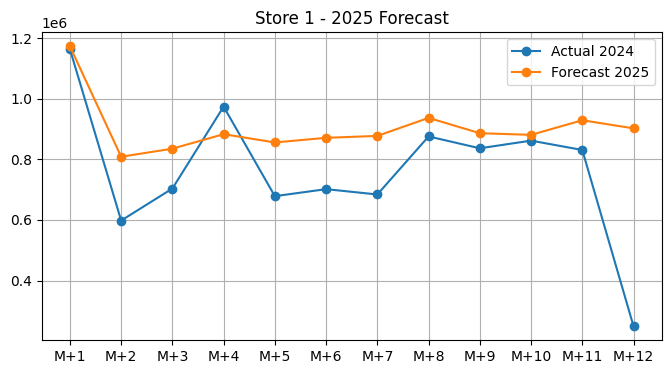

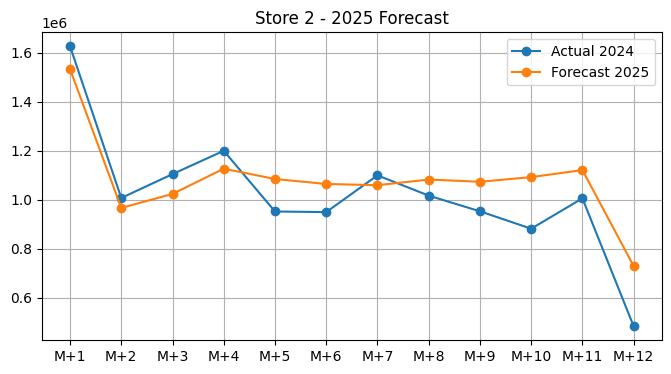

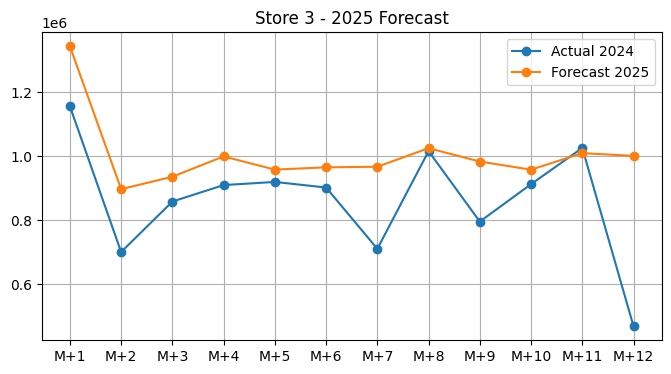

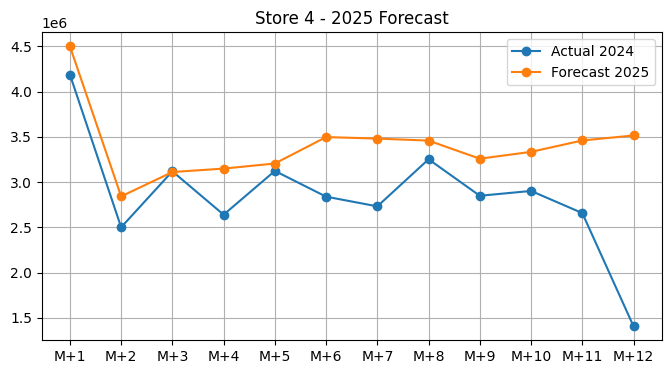

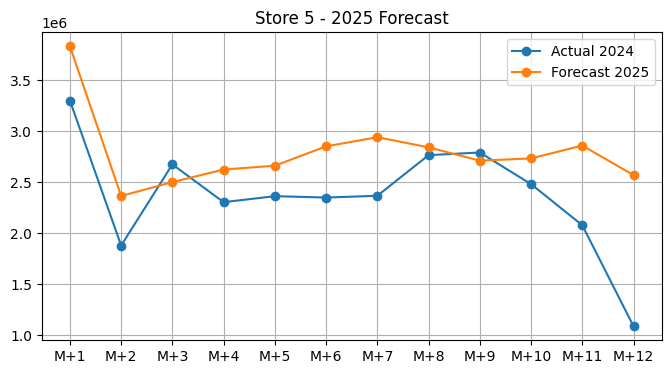

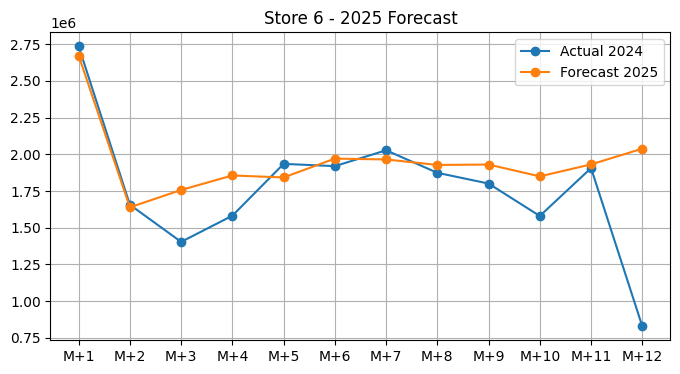

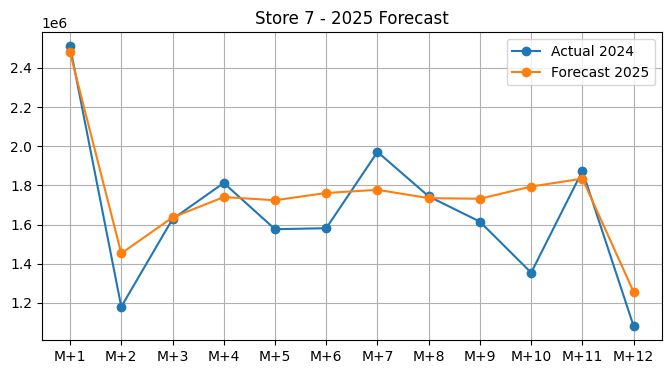

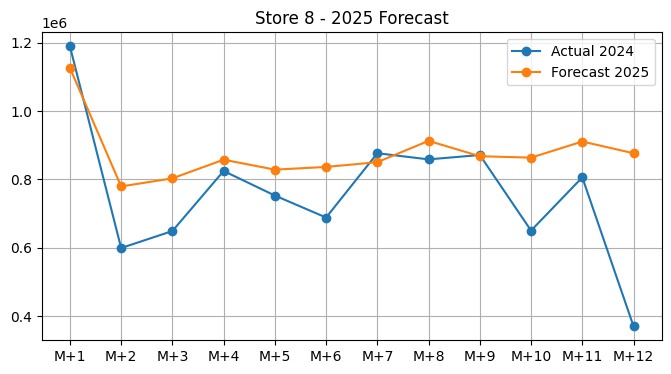

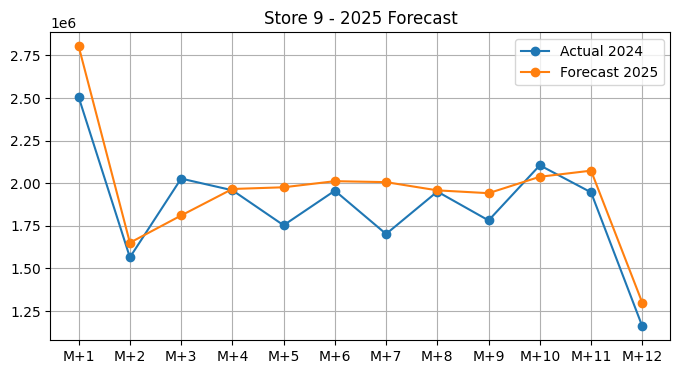

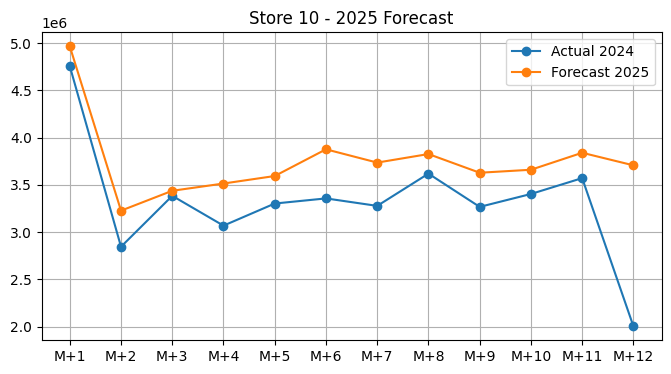

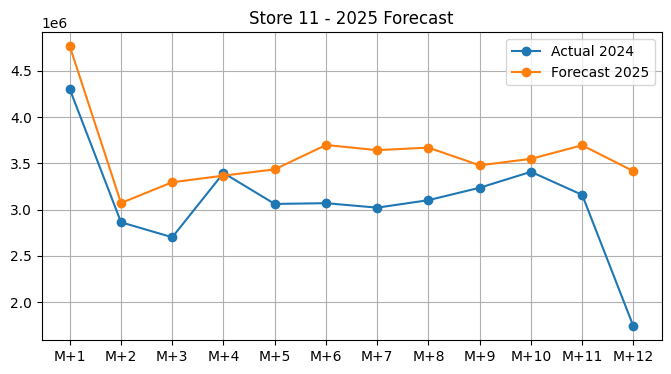

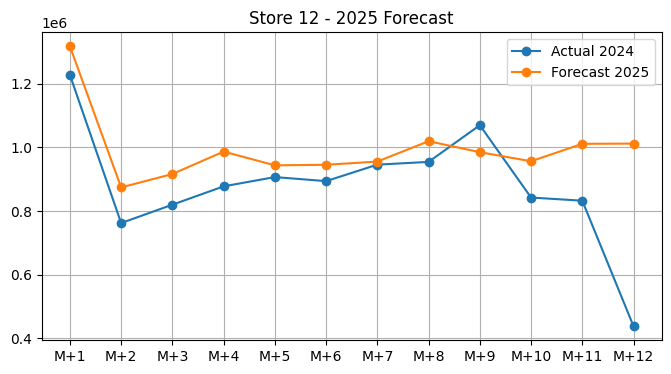

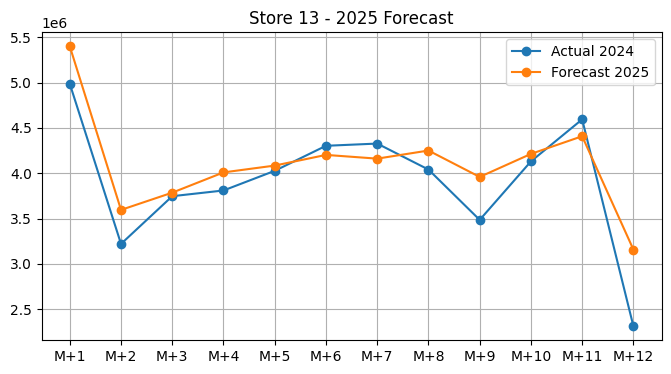

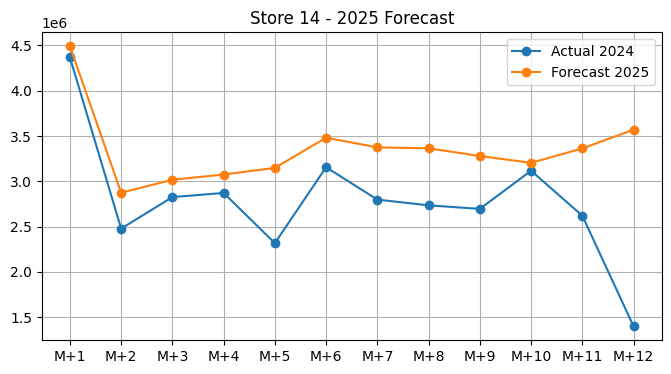

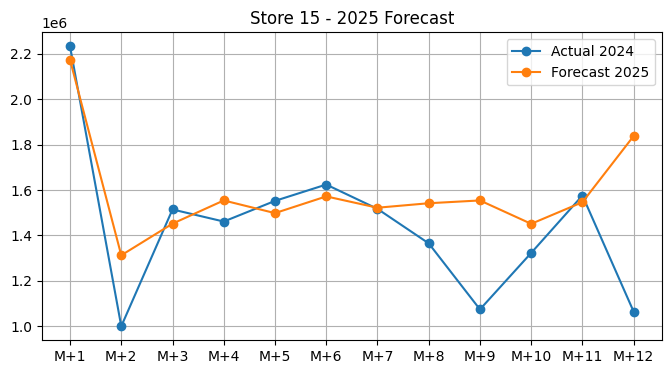

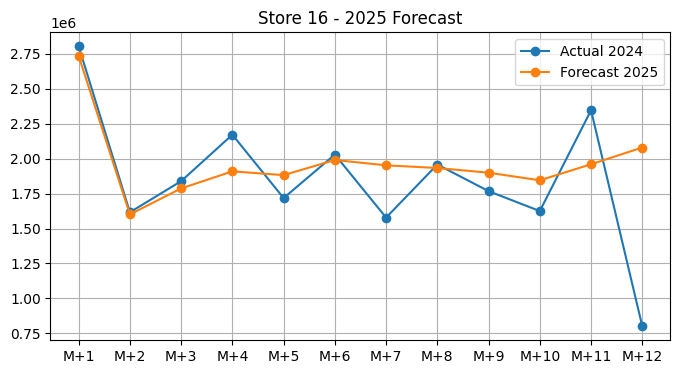

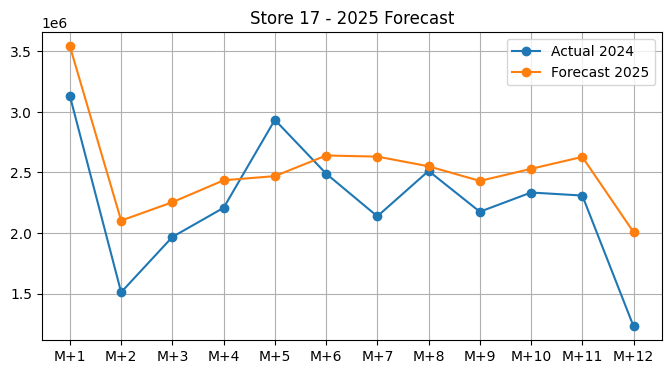

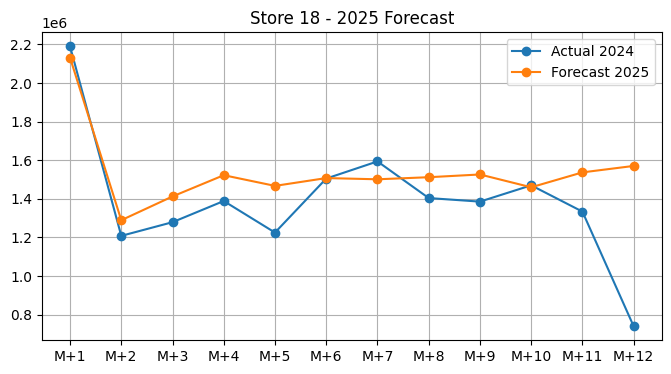

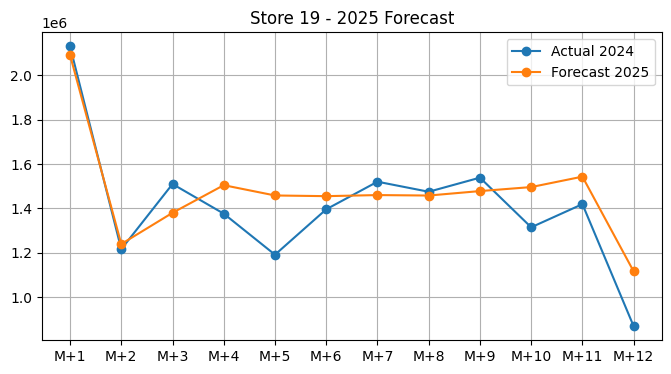

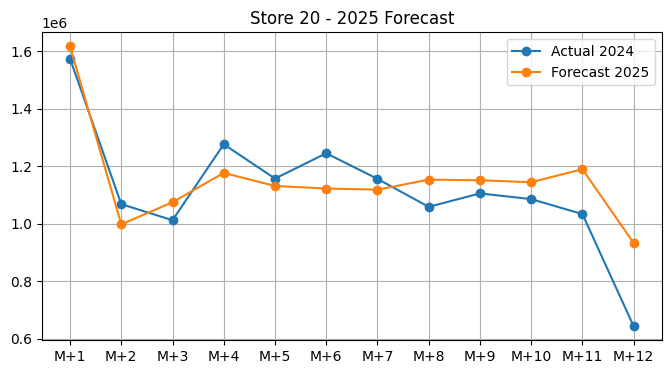

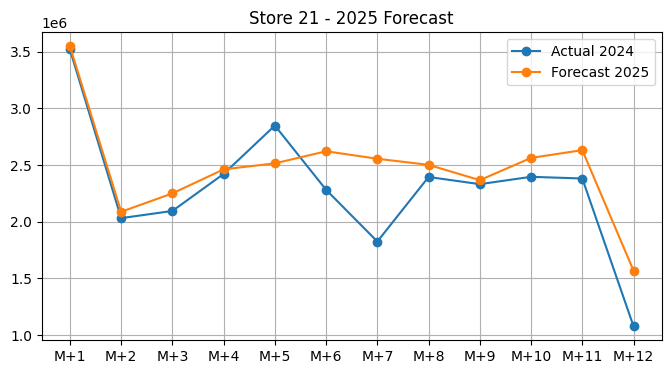

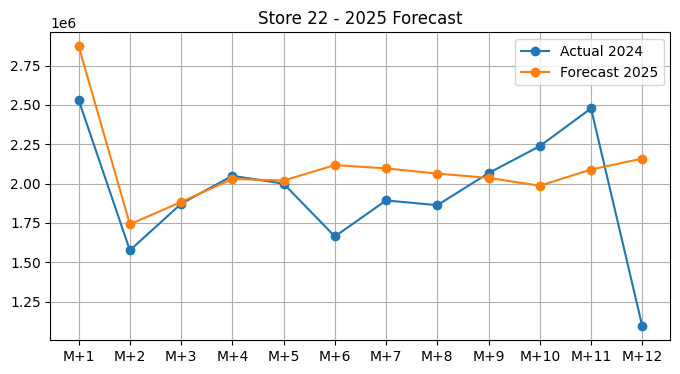

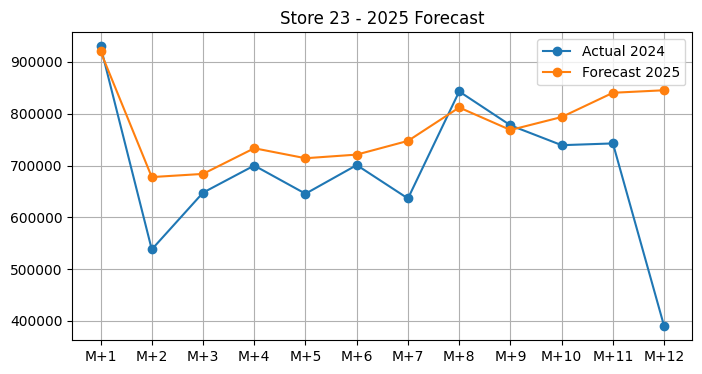

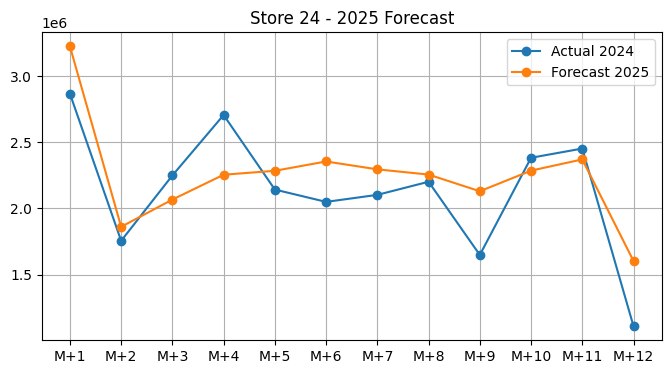

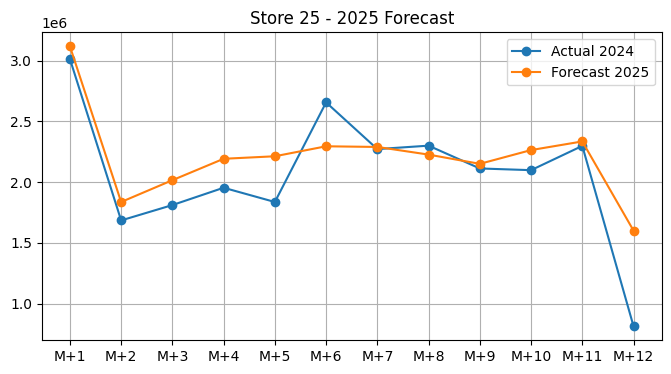

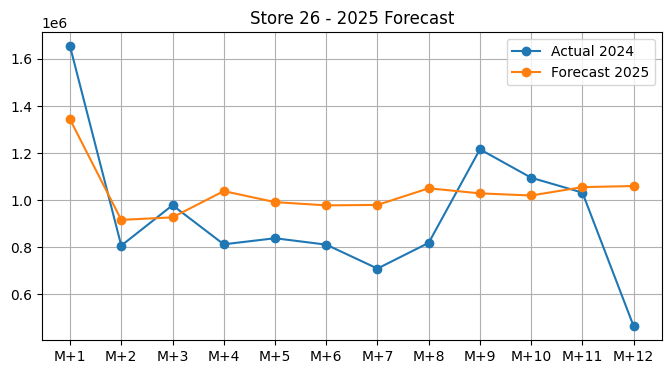

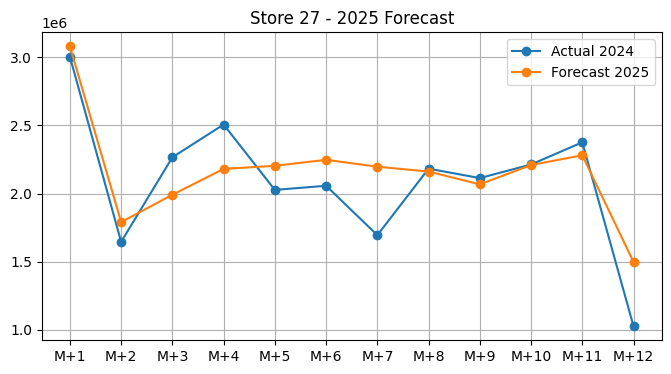

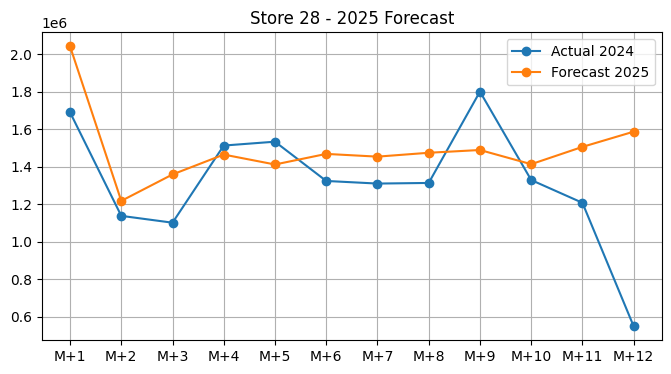

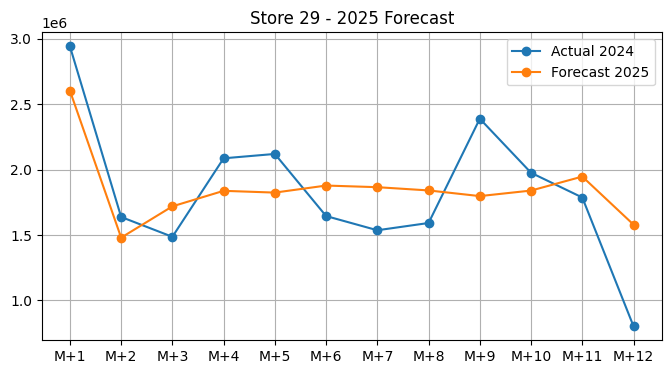

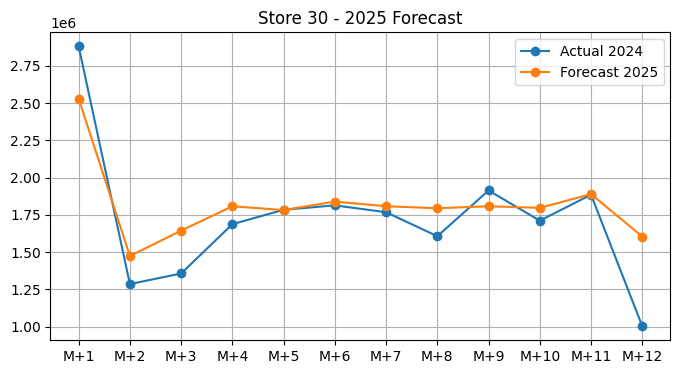

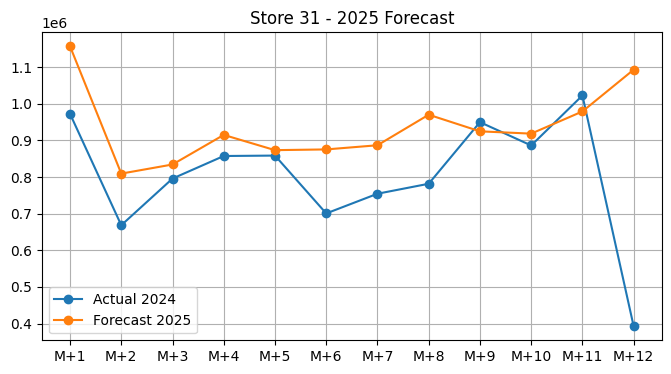

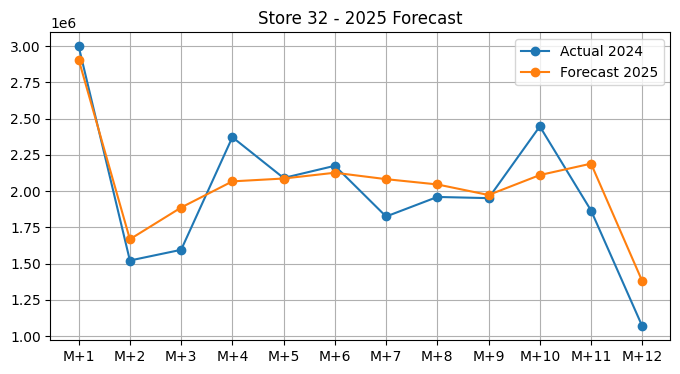

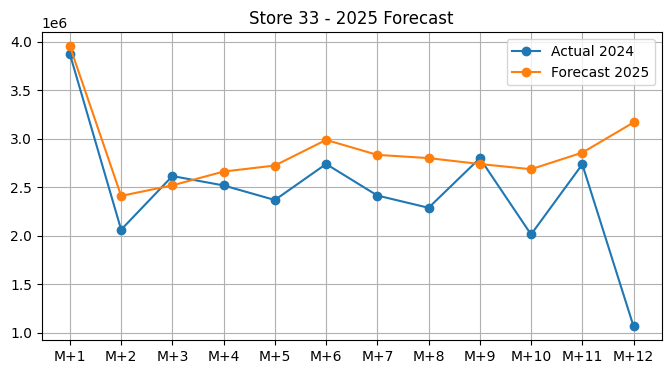

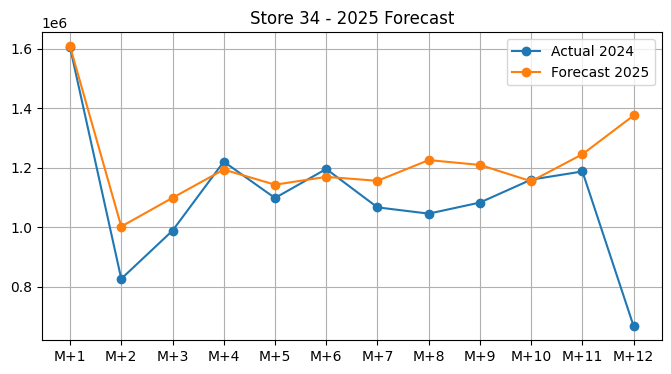

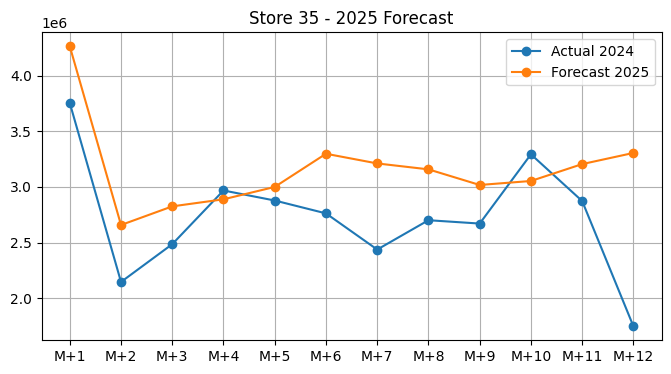

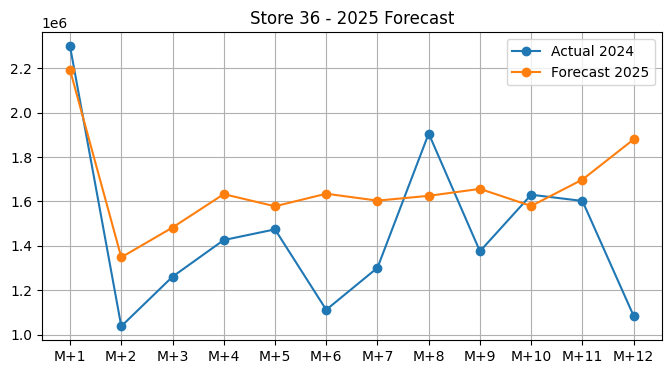

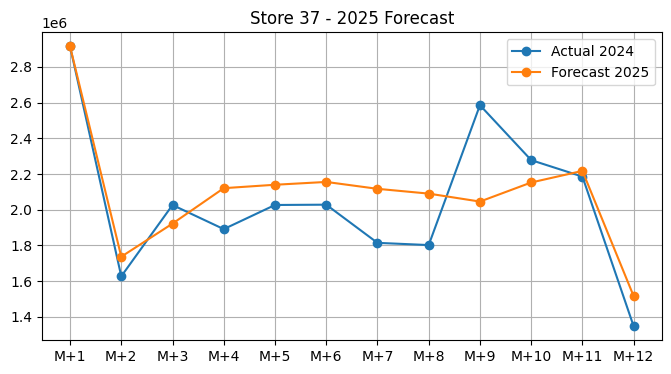

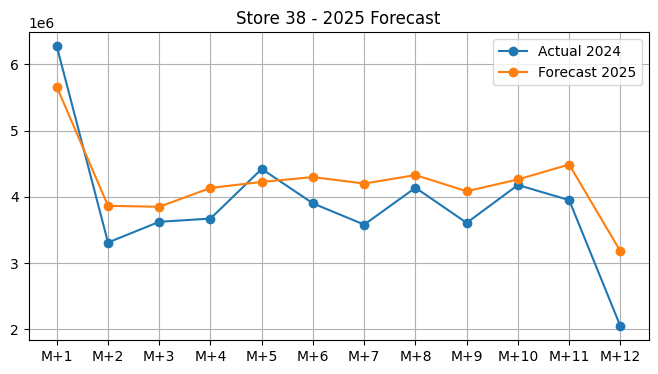

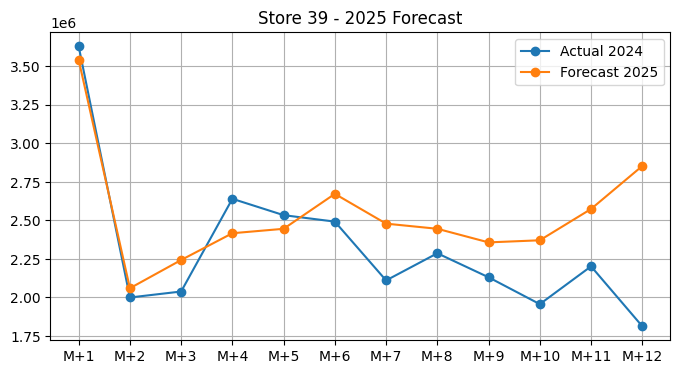

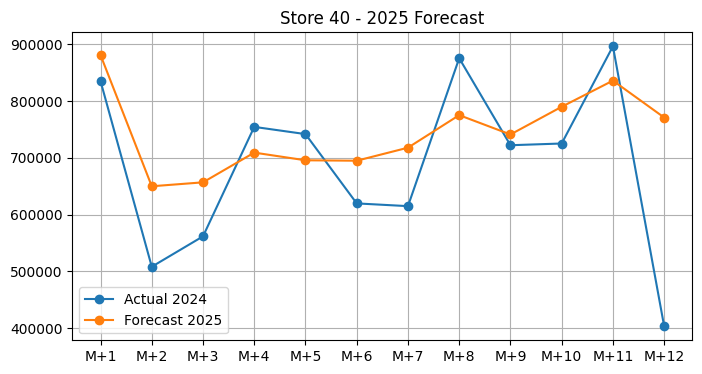

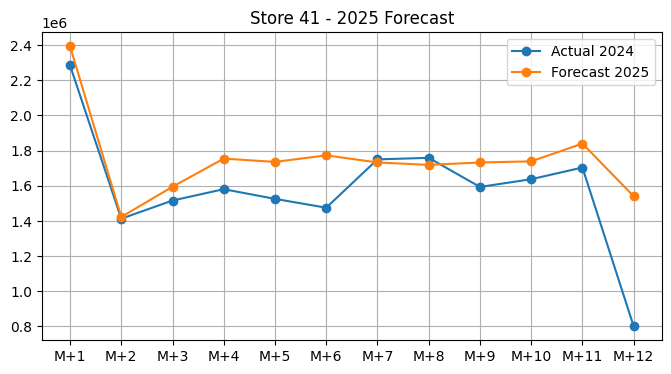

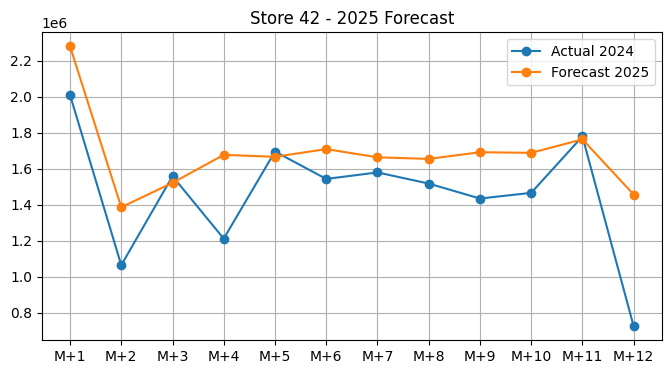

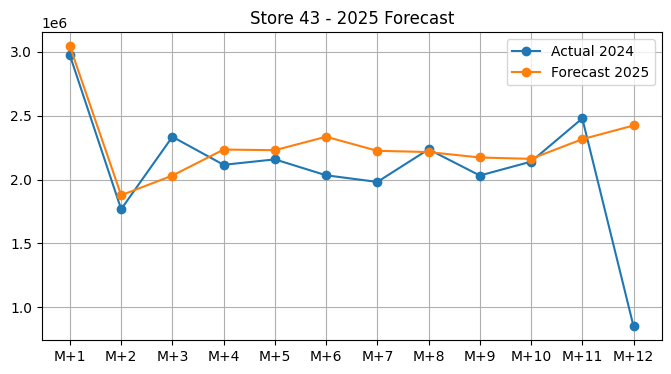

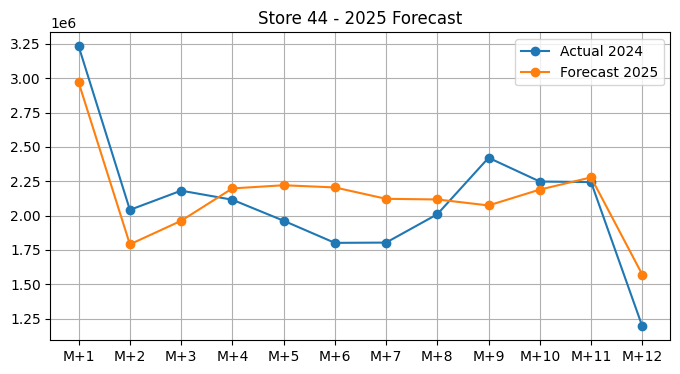

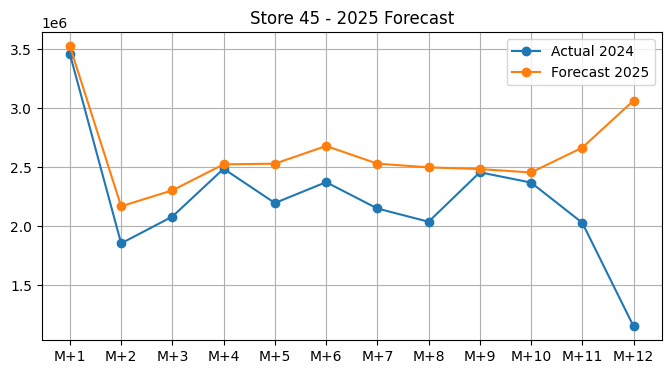

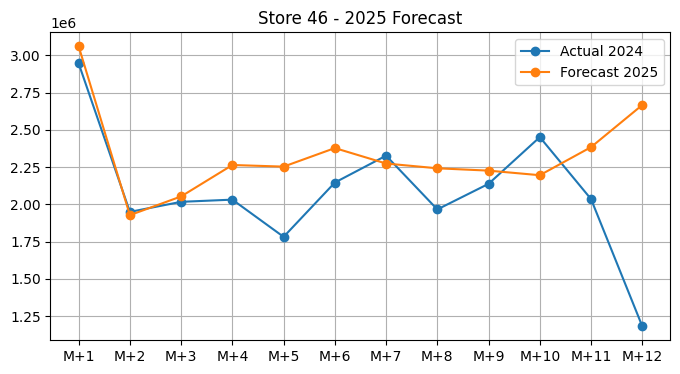

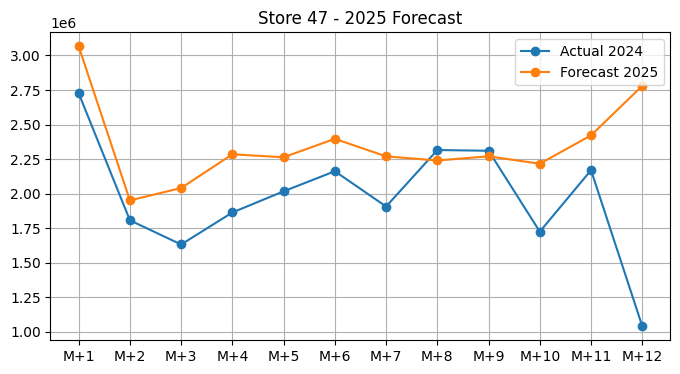

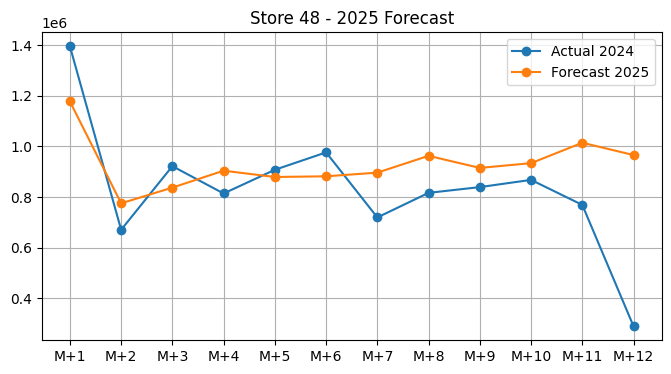

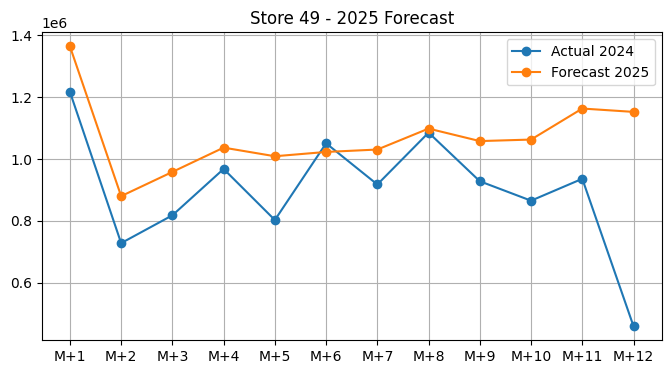

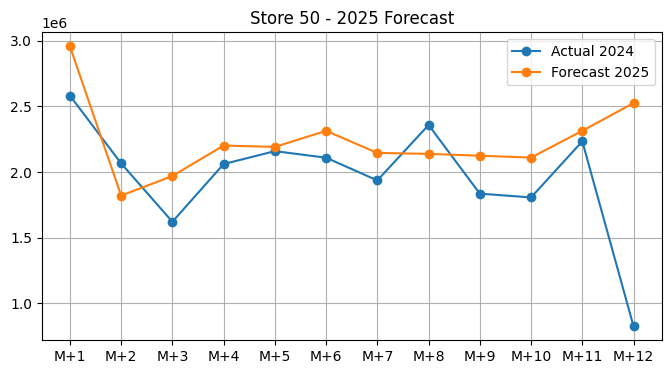

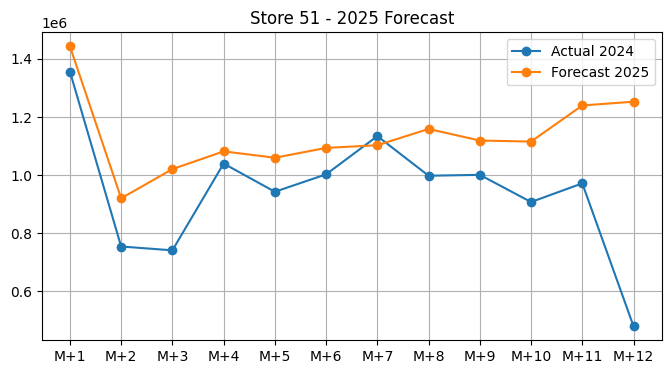

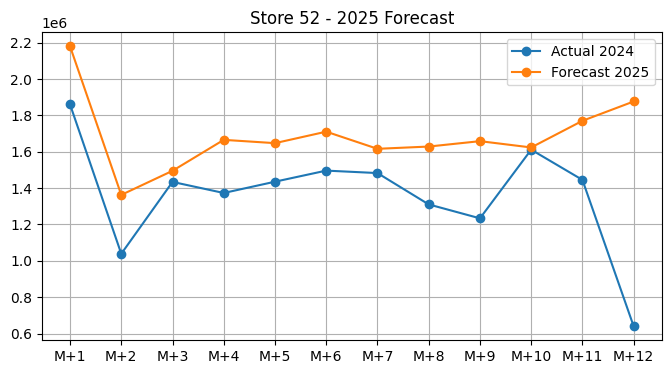

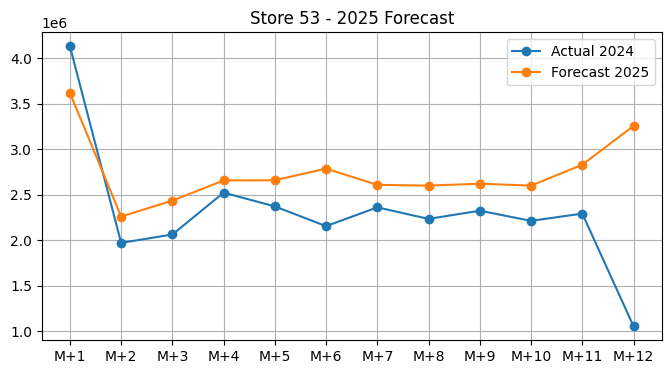

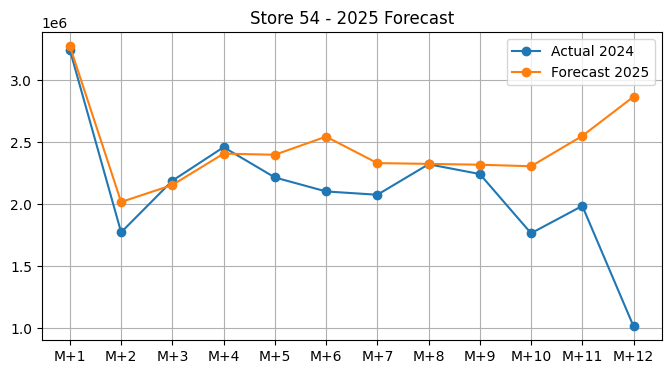

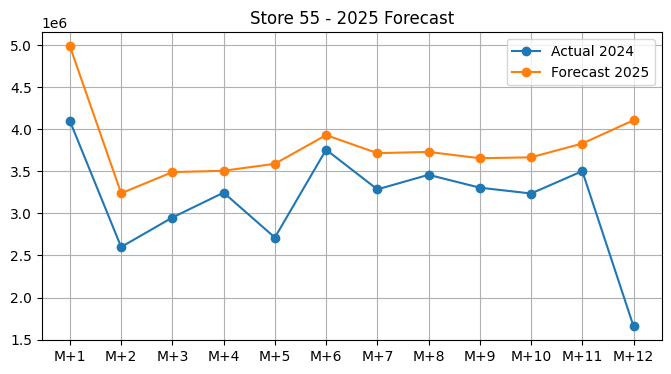

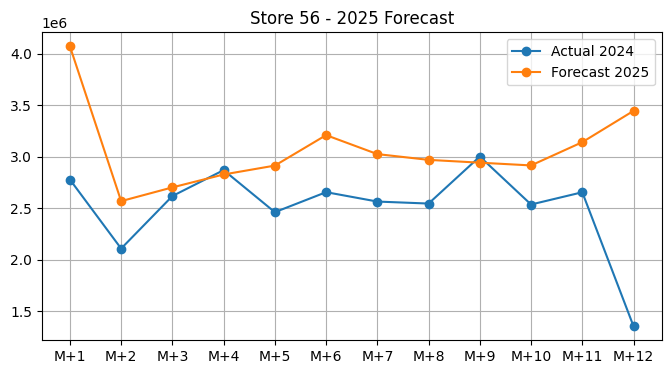

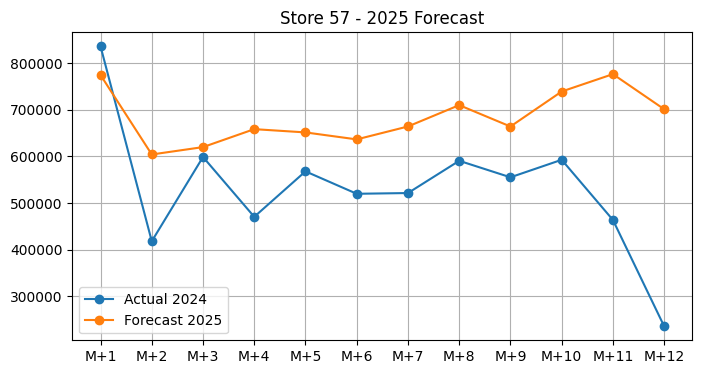

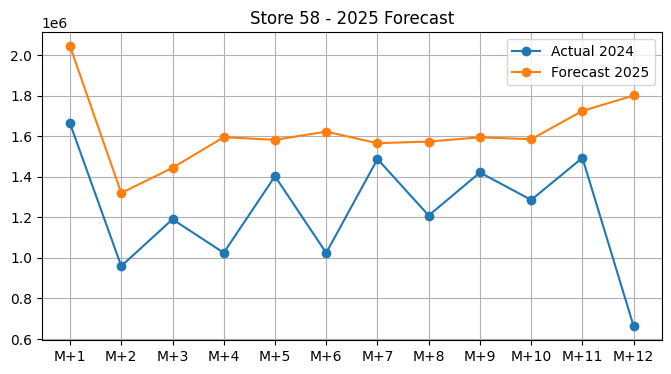

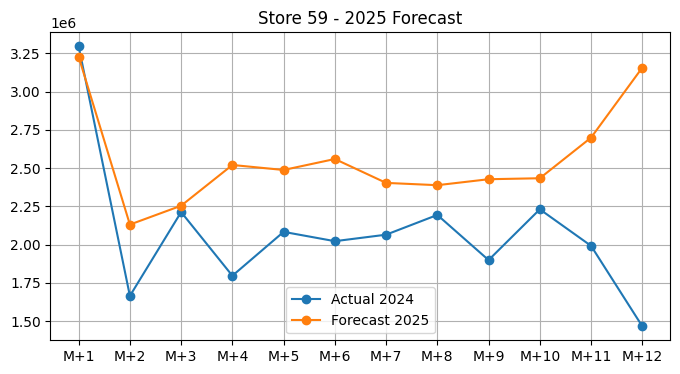

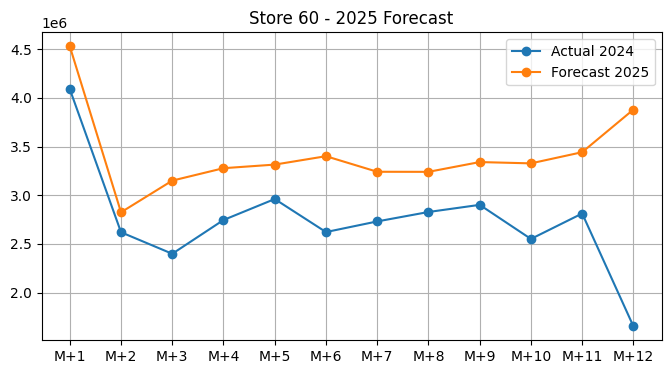

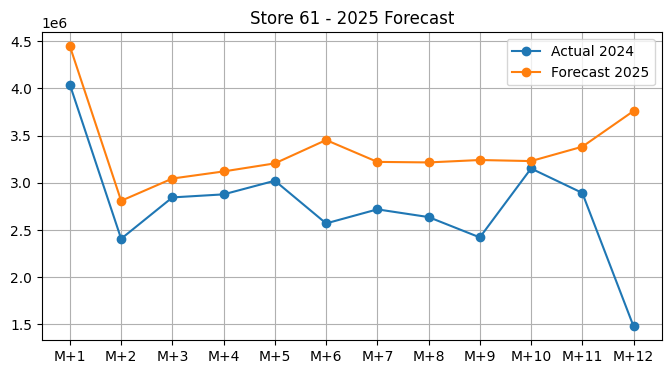

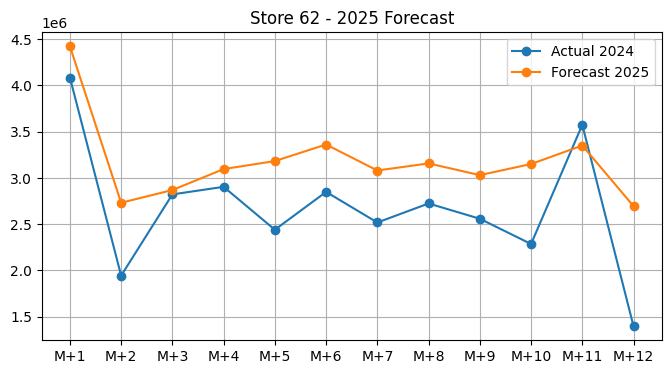

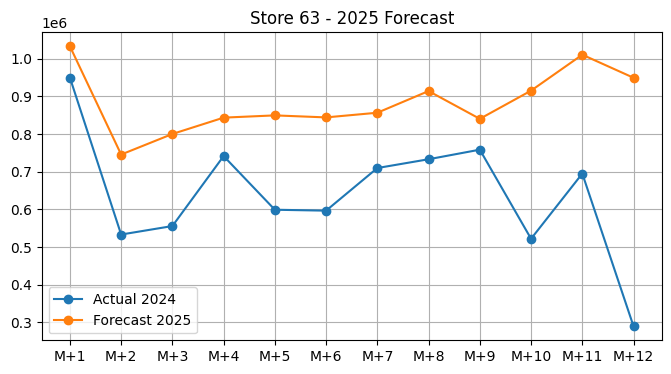

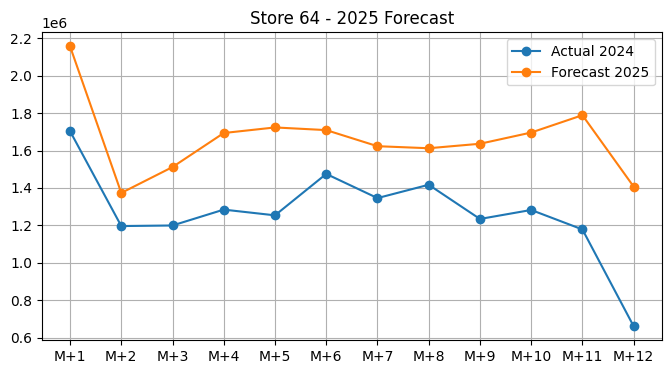

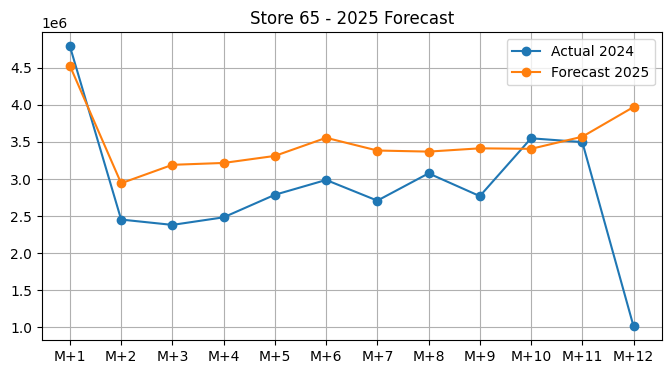

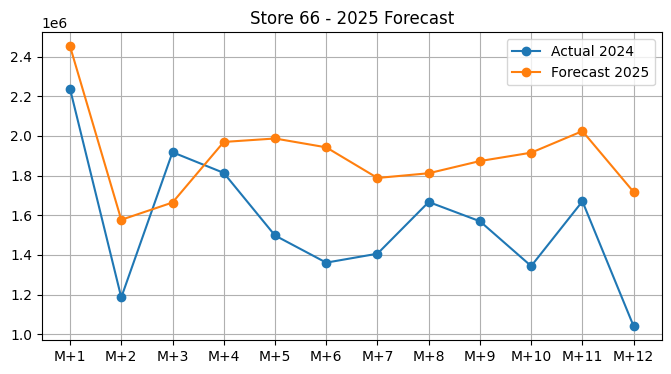

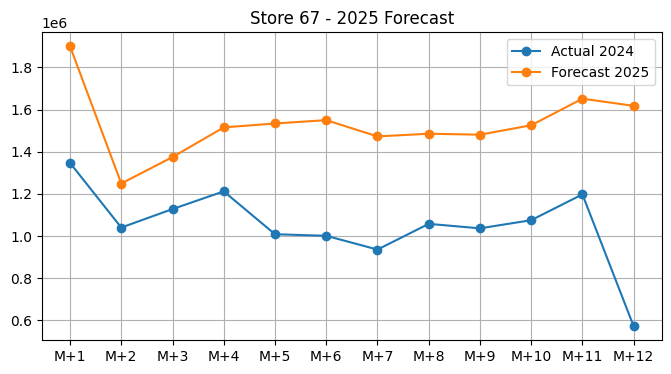

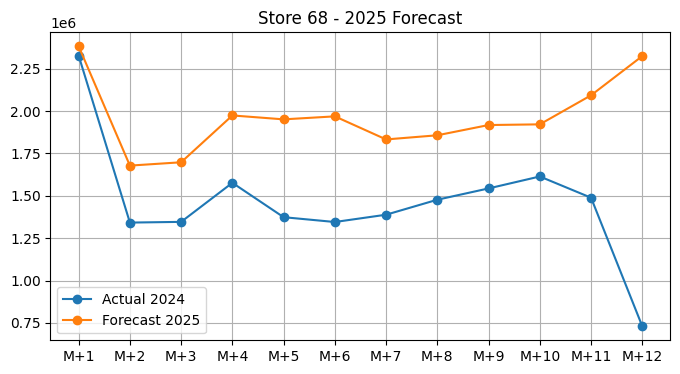

In [31]:
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M')
)
for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date')

    actual_2024 = store_data['sales_amount_realistic'].tail(12).values

    forecast_store = forecast_all_2025[
        forecast_all_2025['store_id'] == store_id
    ]

    forecast_2025 = forecast_store['forecast_2025'].values

    months = [f"M+{i}" for i in range(1,13)]

    plt.figure(figsize=(8,4))

    plt.plot(months, actual_2024, marker='o', label="Actual 2024")
    plt.plot(months, forecast_2025, marker='o', label="Forecast 2025")

    plt.title(f"Store {store_id} - 2025 Forecast")
    plt.legend()
    plt.grid(True)
    plt.show()